In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/Colab Notebooks/dissertation"

/content/drive/MyDrive/Colab Notebooks/dissertation


In [3]:
import sys
sys.path.append("/content/drive/MyDrive/Colab Notebooks/dissertation")

In [4]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Tuple, Dict, Optional
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import GLSAR

In [5]:
df = pd.read_csv("national_merged.csv", parse_dates=["date"])
print(df.head())
print(df.columns)

        date  inflation_rate  unemployment_rate  gdp_rate  \
0 2017-01-01             1.9                4.6       2.5   
1 2017-02-01             2.3                4.6       2.5   
2 2017-03-01             2.3                4.5       2.5   
3 2017-04-01             2.6                4.4       2.5   
4 2017-05-01             2.7                4.4       2.5   

   business_investment_rate  electricity_price_rate  regular_pay_rate  \
0                  0.000000                    -0.2          1.960784   
1                  0.000000                    -0.2          1.735358   
2                  0.000000                     0.8          1.952278   
3                  0.961538                     3.5          1.727862   
4                  0.961538                     7.7          2.380952   

   company_insolvency_rate_per_10k  individual_insolvency_rate_per_10k  
0                             44.9                                19.9  
1                             45.2              

In [6]:
def baseline_ols(
    df: pd.DataFrame,
    y_col: str,
    x_cols: List[str],
    date_col: Optional[str] = None,
    parse_dates: bool = True,
    dropna_if_any: bool = False,
    assert_no_na: bool = True,
    add_intercept: bool = True,
    se_method: Optional[str] = None,
    se_args: Optional[dict] = None,
    make_plots: bool = True
) -> Tuple[sm.regression.linear_model.RegressionResultsWrapper, Dict]:
    """
    Fits a baseline Ordinary Least Squares (OLS) regression model and returns both
    the fitted model object and key diagnostic information.

    This function is at the first stage of the regression ladder. It reads a dataset,
    selects specified variables, fits an OLS model and runs essential diagnostic
    tests such as Durbin–Watson (autocorrelation), Breusch–Pagan (heteroskedasticity),
    and Variance Inflation Factors (multicollinearity). It can also produce standard
    diagnostic plots for model evaluation.

    Parameters:
    df: pd.DataFrame
        A cleaned pandas DataFrame containing dependent and independent variables.
    y_col: str
        Dependent variable column name.
    x_cols: list[str]
        Independent variable (predictor) names.
    date_col: str, optional
        Name of date column for time-series plotting (if available).
    parse_dates: bool, default True
        Parse the date column as datetime if applicable.
    dropna_if_any: bool, default False
        Drop any rows containing missing values.
    assert_no_na: bool, default True
        Raises an error if missing values are detected to notify if somwthing wrong with my data.
    add_intercept: bool, default True
        Adds a constant term B0 to the model.
    se_method: {HC0,HC1,HC2,HC3,HAC}, optional
        Specifies the covariance estimator for standard errors:
            None: classic OLS (assumes homoscedastic (costant variance), independent residuals)
            HC1: heteroscedasticity-consistent (White/Huber–White standard errors)
            HAC: heteroscedasticity and autocorrelation consistent
    se_args: dict, optional
        Additional arguments for covariance estimators.
    make_plots: bool, default True
        If True, creates diagnostic plots:
            1. Residuals vs Fitted values
            2. Q–q plot of residuals
            3. Actual vs Predicted time series (if date_col provided)

    Return:
    model: statsmodels.regression.linear_model.RegressionResultsWrapper
        The fitted OLS model (use .summary() for full results).
    info: dict
        Dictionary containing:
            - data: subset of dataset used in regression
            - diagnostics: Durbin–Watson, Breusch–Pagan, VIF statistics
            - design: model setup details (variable names, covariance settings, etc.)

     Key statistics and what they mean:
     - Coefficients (β) & t-tests:
     Show how each predictor affects insolvency.
     If p<0.05, that variable has a significant effect.
     - F-statistic:
     Tests if the model as a whole explains variation in insolvency.
     Low p-value = model is meaningful.
     - Durbin–Watson (DW):
     Checks if residuals are autocorrelated (move together over time).
     If around 2 is good; if <2, then positive autocorrelation.
     - Breusch–Pagan (BP):
     Tests if residuals have constant variance.
     If p > 0.05 is good; if not, use (HC1) or HAC standard errors.
     - Variance Inflation Factor (VIF):
     Checks if predictors are too correlated.
     1 to 5 is fine; if >10, then high multicollinearity.

    """
    needed = [y_col] + x_cols + ([date_col] if date_col else [])
    df = df[needed].copy()

    # missing-data handling just in case there are issue with my clean data
    if dropna_if_any:
        df.dropna(subset=[y_col] + x_cols, inplace=True)
    if assert_no_na:
        na = df[[y_col] + x_cols].isna().sum()
        if na.any():
            raise ValueError(f"NaNs found in required columns:\n{na[na>0]}\n"
            "Set dropna_if_any=True.")

    if date_col:
        df[date_col] = pd.to_datetime(df[date_col])
        df = df[(df[date_col] >= "2019-01-01") & (df[date_col] <= "2025-02-01")].reset_index(drop=True)

    # building y and x
    y = df[y_col].astype(float)
    X = df[x_cols].astype(float)

    scaler_stats = None

    if add_intercept:
        X = sm.add_constant(X)

    # fitting the OLS model
    fit_kwargs = {}
    if se_method is not None:
        fit_kwargs["cov_type"] = se_method
        if se_method:
            fit_kwargs["cov_kwds"] = se_args
    model = sm.OLS(y, X).fit(**fit_kwargs)

    diagnostics = {}
    diagnostics["durbin_watson"] = float(durbin_watson(model.resid))

    bp_LM, bp_LM_p, bp_F, bp_F_p = het_breuschpagan(model.resid, model.model.exog)
    diagnostics["breusch_pagan"] = {
        "LM": float(bp_LM),
        "LM_pvalue": float(bp_LM_p),
        "F": float(bp_F),
        "F_pvalue": float(bp_F_p)}

    exog = pd.DataFrame(model.model.exog, columns=model.model.exog_names)
    exog_no_const = exog.drop(columns=["const"], errors="ignore")

    vif_data = pd.DataFrame({
        "Variable": exog_no_const.columns,
        "VIF": [variance_inflation_factor(exog_no_const.values, i)
            for i in range(exog_no_const.shape[1])]}).round(3)

    diagnostics["vif"] = vif_data

    # plots
    if make_plots:
        plt.figure(figsize=(9,5))
        plt.scatter(model.fittedvalues, model.resid, s=18)
        plt.axhline(0, linestyle="--")
        plt.title("Residuals vs Fitted")
        plt.xlabel("Fitted values")
        plt.ylabel("Residuals")
        plt.show()

        sm.qqplot(model.resid, line="45")
        plt.title("Q–Q Plot of Residuals")
        plt.show()

        if date_col:
            plt.figure(figsize=(10,5))
            plt.plot(df[date_col], y, label="Actual")
            plt.plot(df[date_col], model.fittedvalues, linestyle="--", label="Predicted")
            plt.title("Actual vs Predicted")
            plt.xlabel("Date")
            plt.ylabel(y_col)
            plt.legend()
            plt.show()

    info = {"data": df,
            "diagnostics": diagnostics,
            "design": {"y_col": y_col,
                       "x_cols": x_cols,
                       "date_col": date_col,
                       "add_intercept": add_intercept,
                       "scaler_stats": scaler_stats,
                       "se_method": se_method,
                       "se_args": se_args}}
    return model, info

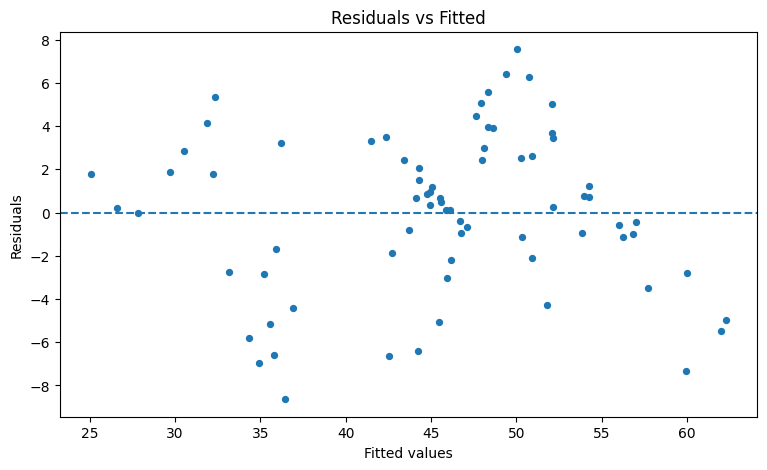

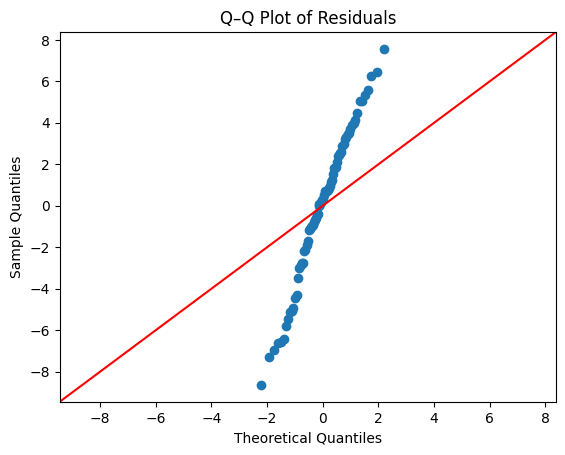

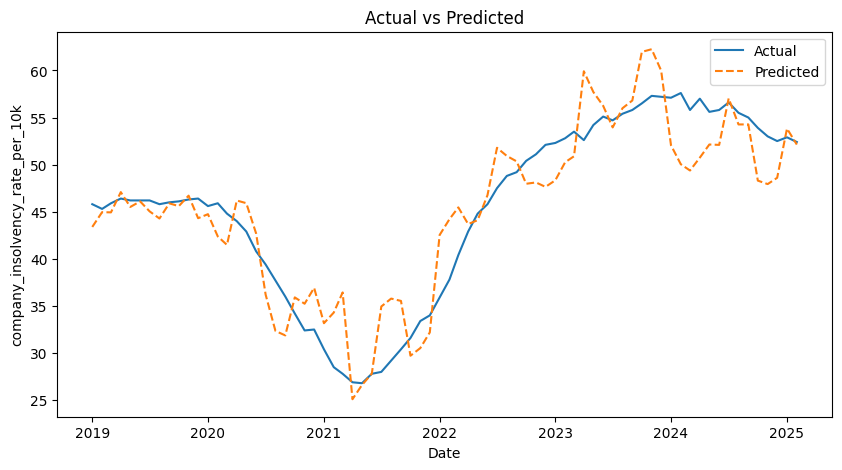

                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.847
Model:                                         OLS   Adj. R-squared:                  0.834
Method:                              Least Squares   F-statistic:                     62.01
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           1.98e-25
Time:                                     21:56:22   Log-Likelihood:                -201.05
No. Observations:                               74   AIC:                             416.1
Df Residuals:                                   67   BIC:                             432.2
Df Model:                                        6                                         
Covariance Type:                         nonrobust                                         
                               coef    std err          t      P>|t|      [0.025

In [7]:
model, info = baseline_ols(
    df=df,
    y_col="company_insolvency_rate_per_10k",
    x_cols=["inflation_rate", "unemployment_rate",
            "gdp_rate", "business_investment_rate",
            "electricity_price_rate", "regular_pay_rate"],
    date_col="date",
    assert_no_na=True,
    se_method=None,
    se_args=None,
    make_plots=True)

print(model.summary())
print(info["diagnostics"])

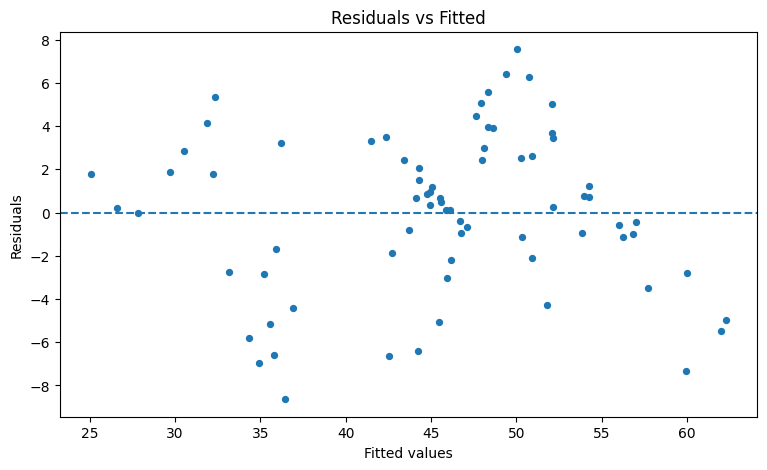

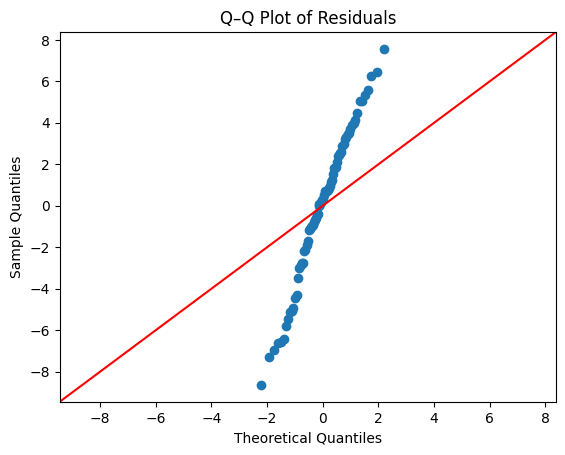

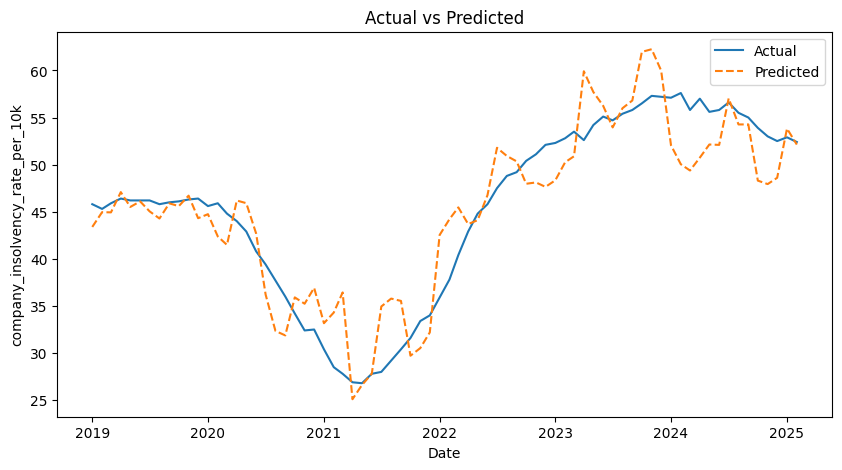

                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.847
Model:                                         OLS   Adj. R-squared:                  0.834
Method:                              Least Squares   F-statistic:                     54.63
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           6.70e-24
Time:                                     21:59:46   Log-Likelihood:                -201.05
No. Observations:                               74   AIC:                             416.1
Df Residuals:                                   67   BIC:                             432.2
Df Model:                                        6                                         
Covariance Type:                               HAC                                         
                               coef    std err          z      P>|z|      [0.025

In [42]:
# When we use se_method="HAC", se_args={"maxlags": 12}, the model keeps the same coefficients (β) and predictors.
# It recalculates the standard errors and p-values to correct for autocorrelation (residuals correlated over time) and heteroskedasticity.
# maxlags=12 means the correction accounts for correlation in residuals up to 12 months back, roughly one year for monthly data.
# This makes the inference (t-tests, F-tests, p-values) statistically validbut does not change how the model itself is structured.
model, info = baseline_ols(
    df=df,
    y_col="company_insolvency_rate_per_10k",
    x_cols=["inflation_rate", "unemployment_rate",
            "gdp_rate", "business_investment_rate",
            "electricity_price_rate", "regular_pay_rate"],
    date_col="date",
    assert_no_na=True,
    se_method="HAC",
    se_args={"maxlags":12},
    make_plots=True)

print(model.summary())
print(info["diagnostics"])

In [9]:
def build_df_master(df: pd.DataFrame) -> pd.DataFrame:
    """
    Creates a master dataset with 12- and 24-month lags for all key macroeconomic predictors
    and a 1- and 12-month lag for the dependent variable (insolvency rate).
    """
    df_master = df.copy()

    # adding lags for dependent variable
    df_master["company_insolvency_rate_lag12"] = df_master["company_insolvency_rate_per_10k"].shift(12)
    df_master["company_insolvency_rate_lag1"] = df_master["company_insolvency_rate_per_10k"].shift(1)

    df_master["individual_insolvency_rate_lag12"] = df_master["individual_insolvency_rate_per_10k"].shift(12)
    df_master["individual_insolvency_rate_lag1"] = df_master["individual_insolvency_rate_per_10k"].shift(1)

    #lags for all the predictors
    lag_map = {
        "inflation_rate": [12, 24],
        "gdp_rate": [12, 24],
        "business_investment_rate": [12, 24],
        "regular_pay_rate": [12, 24],
        "electricity_price_rate": [12, 24],
        "unemployment_rate": [12, 24]}

    for var, Ls in lag_map.items():
        for L in Ls:
            df_master[f"{var}_lag{L}"] = df_master[var].shift(L)

    df_master = df_master.dropna().reset_index(drop=True)
    print(f"{len(df_master)} observations retained")  # to see total observations so I can later check whether my model doesn't iclude them all
    return df_master

In [10]:
df_master = build_df_master(df)
print(df_master.head())


74 observations retained
        date  inflation_rate  unemployment_rate  gdp_rate  \
0 2019-01-01             1.8                4.0       1.3   
1 2019-02-01             1.8                3.8       1.3   
2 2019-03-01             1.8                3.8       1.3   
3 2019-04-01             2.0                3.8       1.5   
4 2019-05-01             1.9                3.9       1.5   

   business_investment_rate  electricity_price_rate  regular_pay_rate  \
0                  0.000000                     3.7          3.750000   
1                  0.000000                     3.8          3.319502   
2                  0.000000                     3.8          3.305785   
3                  3.921569                    14.1          4.140787   
4                  3.921569                    14.0          3.917526   

   company_insolvency_rate_per_10k  individual_insolvency_rate_per_10k  \
0                             45.8                                24.9   
1                    

In [11]:
def add_lag_ols(
    df: pd.DataFrame,
    y_col: str,
    base_x_cols: list,
    date_col: Optional[str] = None,
    se_method: Optional[str] = None,
    se_args: Optional[dict] = None,
    make_plots: bool = True):

    """
    Fits an Ordinary Least Squares (OLS) regression model that can include lagged predictors
    and returns the fitted model, key diagnostic statistics and plots.

    This function is designed for later stages of the regression ladder, where lagged
    variables have already been created and incorporated into the dataset. It takes
    a copy of the data (this mostly used on my df_master dataset, that already includes
    lagged variables), selects the specified dependent and independent variables,
    removes missing values caused by lagging if there are any and estimates an OLS model.
    It then produces key diagnostic tests, including Durbin-Watson (autocorrelation),
    Breusch-Pagan (heteroskedasticity), and Variance Inflation Factors (multicollinearity)
    to assess model validity.

    Parameters:
    df : pandas.DataFrame
        Input dataset (df_master) containing all relevant variables.
    y_col : str
        Dependent variable column name.
    base_x_cols : list of str
        Independent variable names, including any lagged predictors.
    date_col : str, optional
        Name of the date column for time-series plotting.
    se_method: {HC0,HC1,HC2,HC3,HAC}, optional
        Specifies the covariance estimator for standard errors:
            - None: classic OLS (assumes homoscedastic (costant variance), independent residuals)
            - HC1: heteroscedasticity-consistent (White/Huber-White standard errors)
            - HAC: heteroscedasticity and autocorrelation consistent
    se_args : dict, optional
        Additional arguments for the chosen covariance estimator.
    make_plots : bool, default True
        If True, generates diagnostic plots:
            1. Residuals vs Fitted values
            2. Q–Q plot of residuals
            3. Actual vs Predicted series

    Returns:
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        The fitted OLS model object.
    diagnostics : dict
        Dictionary containing Durbin-Watson, Breusch-Pagan and VIF results.
    x_cols : list of str
        List of predictors included in the final model.
    """
    df2=df.copy()
    x_cols = base_x_cols.copy()
    needed = [y_col] + x_cols + ([date_col] if date_col else [])
    df2 = df2[needed].dropna().reset_index(drop=True)

    # y, X, const
    y = df2[y_col].astype(float)
    X = df2[x_cols].astype(float)
    X = sm.add_constant(X)

    fit_kwargs = {}
    if se_method is not None:
        fit_kwargs["cov_type"] = se_method
        if se_args:
            fit_kwargs["cov_kwds"] = se_args
    model = sm.OLS(y, X).fit(**fit_kwargs)

    #diagnostics
    diagnostics = {}
    diagnostics["durbin_watson"] = float(durbin_watson(model.resid))

    bp_LM, bp_LM_p, bp_F, bp_F_p = het_breuschpagan(model.resid, model.model.exog)
    diagnostics["breusch_pagan"] = {
        "LM": float(bp_LM),
        "LM_pvalue": float(bp_LM_p),
        "F": float(bp_F),
        "F_pvalue": float(bp_F_p)}

    exog = pd.DataFrame(model.model.exog, columns=model.model.exog_names)
    exog_no_const = exog.drop(columns=["const"], errors="ignore")

    vif = pd.DataFrame({
        "Variable": exog_no_const.columns,
        "VIF": [variance_inflation_factor(exog_no_const.values, i)
            for i in range(exog_no_const.shape[1])]}).round(3)

    diagnostics["vif"] = vif

    # plots
    if make_plots:
        plt.figure(figsize=(9,5))
        plt.scatter(model.fittedvalues, model.resid, s=18)
        plt.axhline(0, ls="--"); plt.title("Residuals vs Fitted (stepwise lag)"); plt.show()
        sm.qqplot(model.resid, line="45"); plt.title("Q–Q Plot (stepwise lag)"); plt.show()
        if date_col:
            plt.figure(figsize=(10,5))
            plt.plot(df2[date_col], y, label="Actual")
            plt.plot(df2[date_col], model.fittedvalues, "--", label="Predicted")
            plt.legend(); plt.title("Actual vs Predicted (includes lags)"); plt.show()

    return model, diagnostics, x_cols

In [12]:
# checking correlation between variables to see why VIF could explode so much
df_master[["company_insolvency_rate_per_10k","inflation_rate",
           "inflation_rate_lag12", "inflation_rate_lag24",
           "unemployment_rate", "unemployment_rate_lag12",
           "unemployment_rate_lag24", "gdp_rate", "gdp_rate_lag12",
           "gdp_rate_lag24","business_investment_rate",
           "business_investment_rate_lag12", "business_investment_rate_lag24",
           "electricity_price_rate", "electricity_price_rate_lag12",
           "electricity_price_rate_lag24", "regular_pay_rate",
           "regular_pay_rate_lag12", "regular_pay_rate_lag24"]].corr().round(3)

,company_insolvency_rate_per_10k,inflation_rate,inflation_rate_lag12,inflation_rate_lag24,unemployment_rate,unemployment_rate_lag12,unemployment_rate_lag24,gdp_rate,gdp_rate_lag12,gdp_rate_lag24,business_investment_rate,business_investment_rate_lag12,business_investment_rate_lag24,electricity_price_rate,electricity_price_rate_lag12,electricity_price_rate_lag24,regular_pay_rate,regular_pay_rate_lag12,regular_pay_rate_lag24
company_insolvency_rate_per_10k,1.000,0.424,0.829,0.497,-0.467,-0.427,0.314,-0.209,0.496,0.228,0.157,0.617,0.134,-0.012,0.541,0.380,0.335,0.751,0.399
inflation_rate,0.424,1.000,0.359,-0.256,-0.510,0.162,0.642,0.250,0.526,-0.259,0.458,0.356,-0.319,0.766,0.283,-0.246,0.630,0.382,0.112
inflation_rate_lag12,0.829,0.359,1.000,0.454,-0.126,-0.474,0.111,-0.127,0.244,0.499,0.131,0.490,0.372,-0.207,0.812,0.326,0.561,0.679,0.590
inflation_rate_lag24,0.497,-0.256,0.454,1.000,0.172,-0.178,-0.512,-0.058,-0.139,0.279,0.059,0.134,0.471,-0.654,-0.025,0.970,0.120,0.568,0.598
unemployment_rate,-0.467,-0.510,-0.126,0.172,1.000,-0.246,-0.493,-0.185,-0.410,0.226,-0.359,-0.203,0.327,-0.470,-0.129,0.221,-0.043,-0.258,0.337
unemployment_rate_lag12,-0.427,0.162,-0.474,-0.178,-0.246,1.000,-0.239,0.517,-0.186,-0.411,0.274,-0.368,-0.232,0.227,-0.452,-0.095,-0.067,-0.047,-0.351
unemployment_rate_lag24,0.314,0.642,0.111,-0.512,-0.493,-0.239,1.000,-0.068,0.512,-0.176,0.181,0.245,-0.347,0.755,0.209,-0.528,0.252,-0.120,-0.106
gdp_rate,-0.209,0.250,-0.127,-0.058,-0.185,0.517,-0.068,1.000,-0.437,-0.088,0.879,-0.579,0.080,0.181,-0.185,0.025,0.550,-0.218,0.020
gdp_rate_lag12,0.496,0.526,0.244,-0.139,-0.410,-0.186,0.512,-0.437,1.000,-0.436,-0.162,0.883,-0.588,0.522,0.201,-0.202,0.005,0.523,-0.254
gdp_rate_lag24,0.228,-0.259,0.499,0.279,0.226,-0.411,-0.176,-0.088,-0.436,1.000,-0.073,-0.165,0.903,-0.593,0.554,0.198,0.179,-0.005,0.611


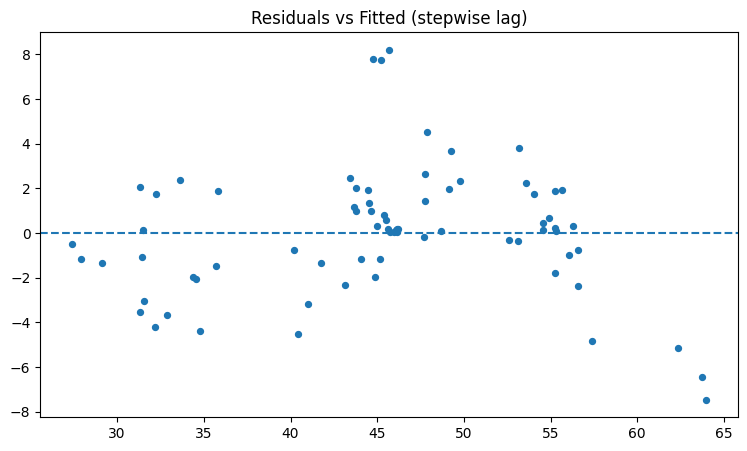

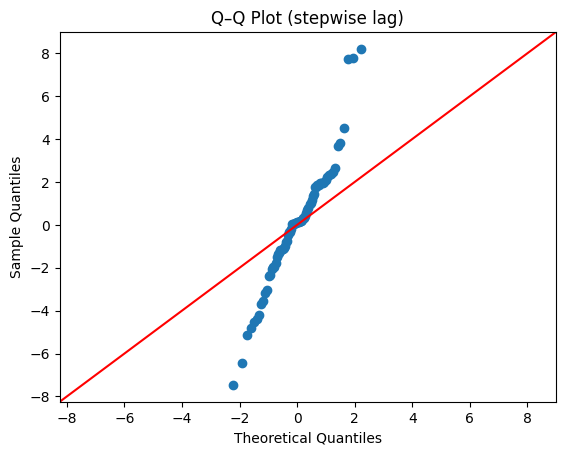

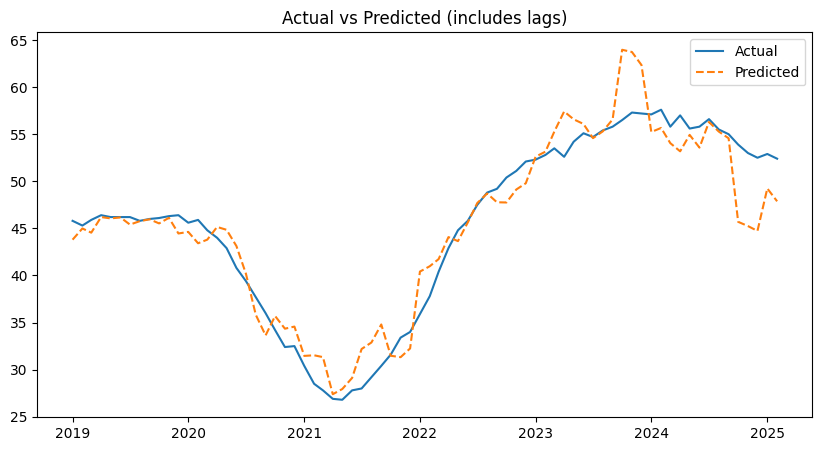

['inflation_rate', 'unemployment_rate', 'gdp_rate', 'business_investment_rate', 'electricity_price_rate', 'regular_pay_rate', 'inflation_rate_lag12']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.908
Model:                                         OLS   Adj. R-squared:                  0.899
Method:                              Least Squares   F-statistic:                     58.93
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           6.06e-26
Time:                                     21:56:25   Log-Likelihood:                -182.21
No. Observations:                               74   AIC:                             380.4
Df Residuals:                                   66   BIC:                             398.8
Df Model:                                        7                                         
Covariance Type:      

In [13]:
#model with all variables + inflation lag 12
model_infl_lag12, diag_infl_lag12, xcols_used = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["inflation_rate",
                 "unemployment_rate", "gdp_rate",
                 "business_investment_rate", "electricity_price_rate",
                 "regular_pay_rate", "inflation_rate_lag12"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12}
)
print(xcols_used)
print(model_infl_lag12.summary())
print(diag_infl_lag12)

In [14]:
# creating helper regression to see how much regular pay data can be explained by other variables (due to exploded VIF earlier)
# we see that its largely explained by them, so I decided to remove this variable from the data after figuring out what lags
# for inflation I will keep (if any)
X = sm.add_constant(df_master[["inflation_rate","inflation_rate_lag12",
                               "inflation_rate_lag24","unemployment_rate",
                               "gdp_rate","business_investment_rate","electricity_price_rate"]])
y = df_master["regular_pay_rate"]
helper = sm.OLS(y, X).fit()
print(f"R² predicting wages = {helper.rsquared:.4f}")
print(f"Expected VIF ≈ {1/(1-helper.rsquared):.1f}")

R² predicting wages = 0.9068
Expected VIF ≈ 10.7


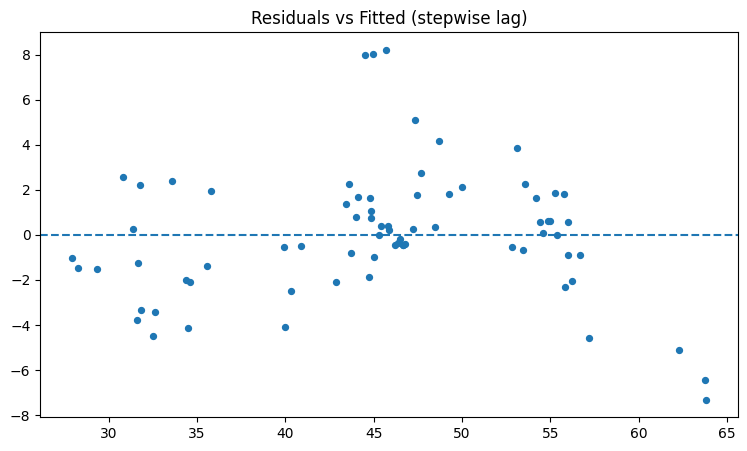

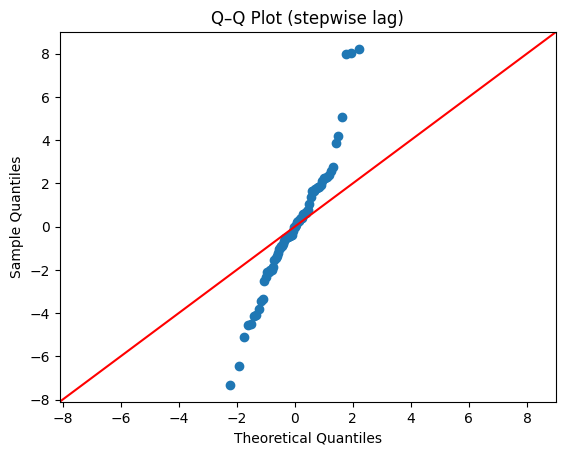

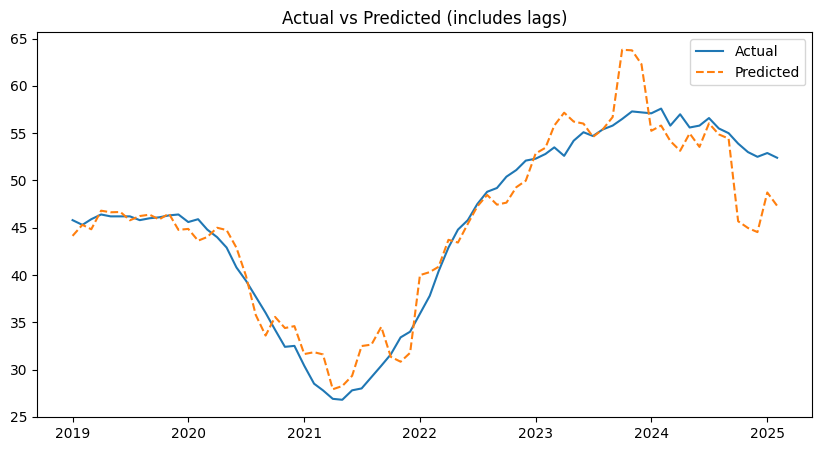

['unemployment_rate', 'gdp_rate', 'business_investment_rate', 'electricity_price_rate', 'regular_pay_rate', 'inflation_rate_lag12']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.907
Model:                                         OLS   Adj. R-squared:                  0.899
Method:                              Least Squares   F-statistic:                     55.07
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           5.37e-24
Time:                                     21:56:26   Log-Likelihood:                -182.67
No. Observations:                               74   AIC:                             379.3
Df Residuals:                                   67   BIC:                             395.5
Df Model:                                        6                                         
Covariance Type:                        

In [15]:
# checking model only for inflation that is lagged 12 month due to current inflation
# being insignificant in the previous model
model_infl_onlylag12, diag_infl_onlylag12, xcols_used2 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate",
                 "business_investment_rate", "electricity_price_rate",
                 "regular_pay_rate", "inflation_rate_lag12"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used2)
print(model_infl_onlylag12.summary())
print(diag_infl_onlylag12)

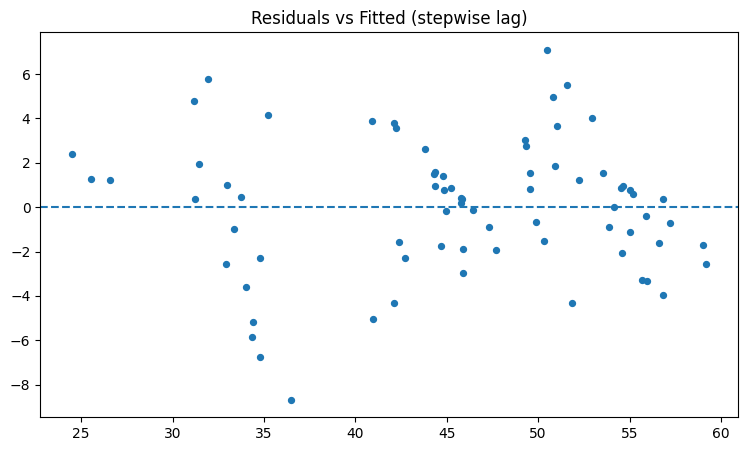

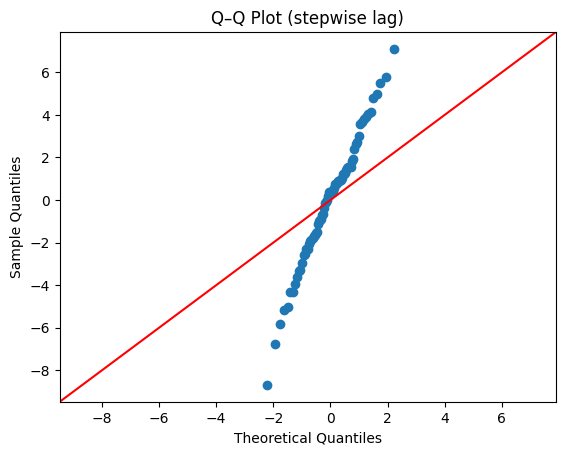

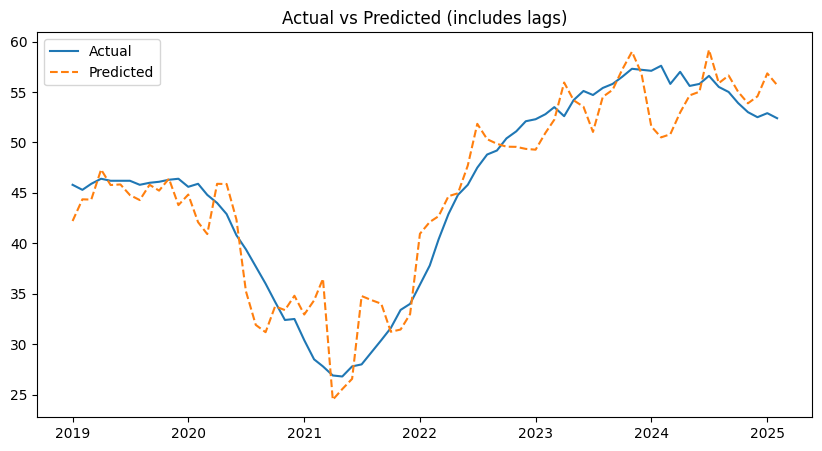

['inflation_rate', 'unemployment_rate', 'gdp_rate', 'business_investment_rate', 'electricity_price_rate', 'regular_pay_rate', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.897
Model:                                         OLS   Adj. R-squared:                  0.886
Method:                              Least Squares   F-statistic:                     257.9
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           2.29e-45
Time:                                     21:56:28   Log-Likelihood:                -186.51
No. Observations:                               74   AIC:                             389.0
Df Residuals:                                   66   BIC:                             407.5
Df Model:                                        7                                         
Covariance Type:      

In [16]:
# checking model with all initial variables + inflation lag 24
model_infl_lag24, diag_infl_lag24, xcols_used3 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["inflation_rate", "unemployment_rate", "gdp_rate",
                 "business_investment_rate", "electricity_price_rate",
                 "regular_pay_rate", "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used3)
print(model_infl_lag24.summary())
print(diag_infl_lag24)

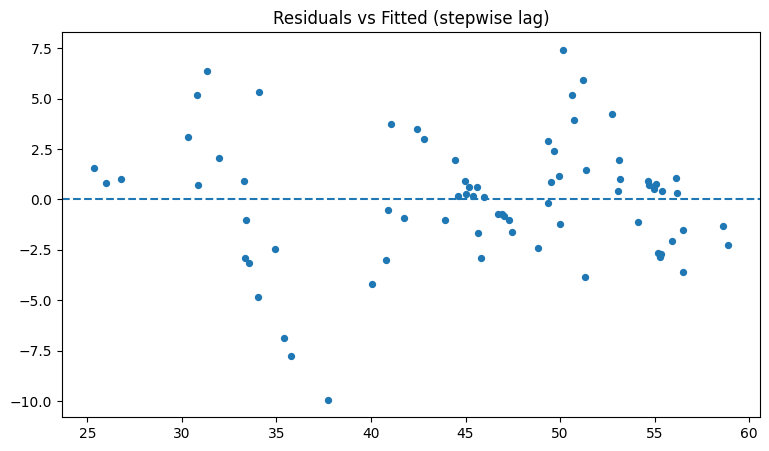

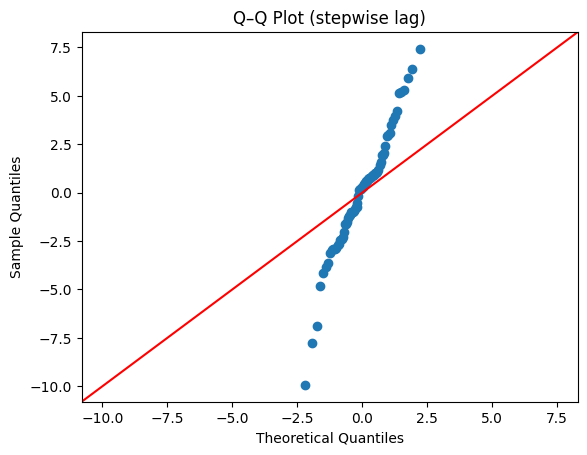

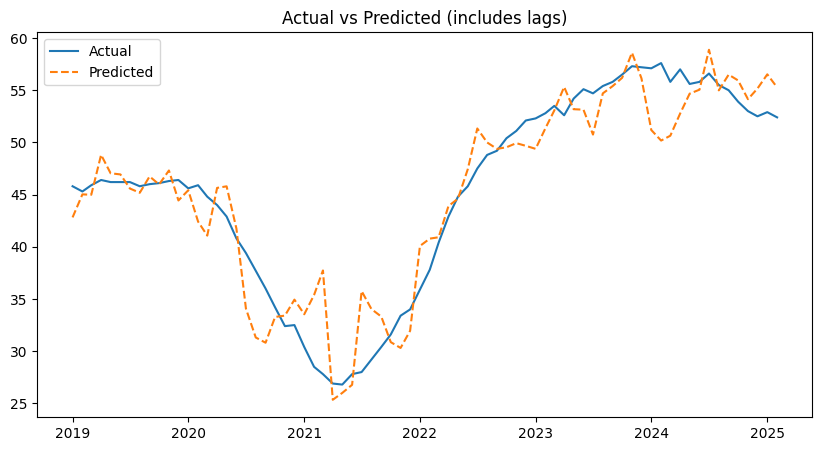

['unemployment_rate', 'gdp_rate', 'business_investment_rate', 'electricity_price_rate', 'regular_pay_rate', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.891
Model:                                         OLS   Adj. R-squared:                  0.882
Method:                              Least Squares   F-statistic:                     301.7
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           1.85e-46
Time:                                     21:56:29   Log-Likelihood:                -188.44
No. Observations:                               74   AIC:                             390.9
Df Residuals:                                   67   BIC:                             407.0
Df Model:                                        6                                         
Covariance Type:                        

In [17]:
# checking model for inflation only with 24 lags as original inflation was insignifican in the model before
model_infl_onlylag24, diag_infl_onlylag24, xcols_used4 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate",
                 "business_investment_rate", "electricity_price_rate",
                 "regular_pay_rate", "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used4)
print(model_infl_onlylag24.summary())
print(diag_infl_onlylag24)

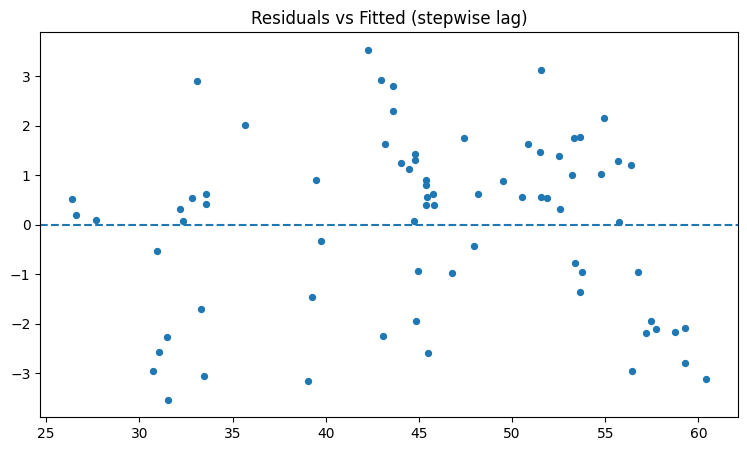

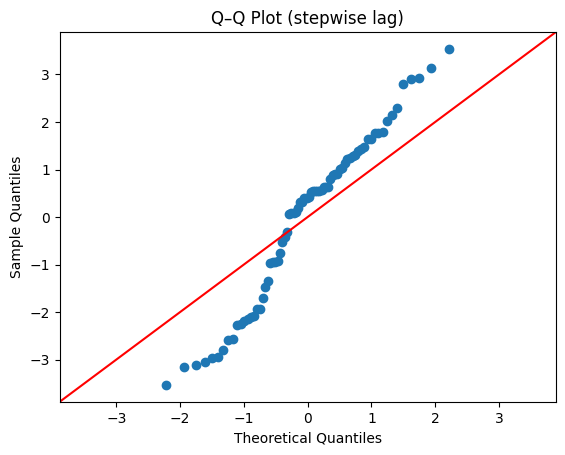

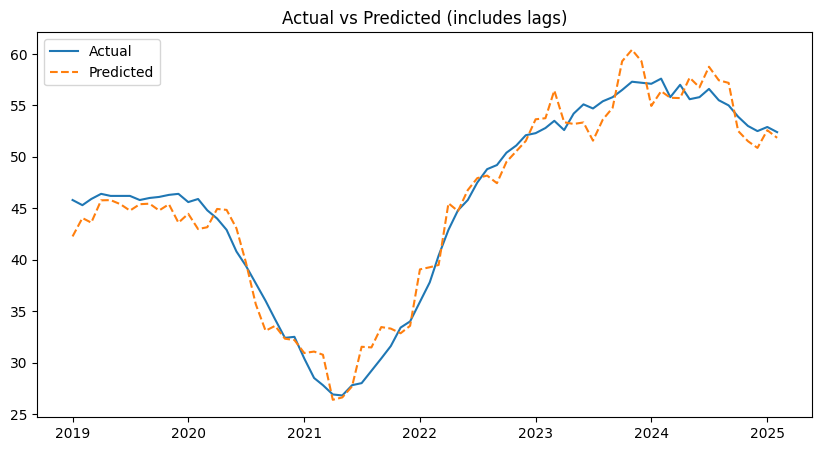

['unemployment_rate', 'gdp_rate', 'business_investment_rate', 'electricity_price_rate', 'regular_pay_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.965
Model:                                         OLS   Adj. R-squared:                  0.962
Method:                              Least Squares   F-statistic:                     297.3
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           2.48e-47
Time:                                     21:56:29   Log-Likelihood:                -146.36
No. Observations:                               74   AIC:                             308.7
Df Residuals:                                   66   BIC:                             327.1
Df Model:                                        7                                         
Covariance Type:

In [18]:
# @title Default title text
# since both 12 lag and 24 lag inflation were significant, we check the model that includes them both, showing
# that both inflation vars with lags are significant, DW also improved as well as AIC and BIC decrease,
# indicating better fit then models before
model_infl_12and24, diag_infl_12and24, xcols_used5 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate",
                 "business_investment_rate", "electricity_price_rate",
                 "regular_pay_rate","inflation_rate_lag12", "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used5)
print(model_infl_12and24.summary())
print(diag_infl_12and24)

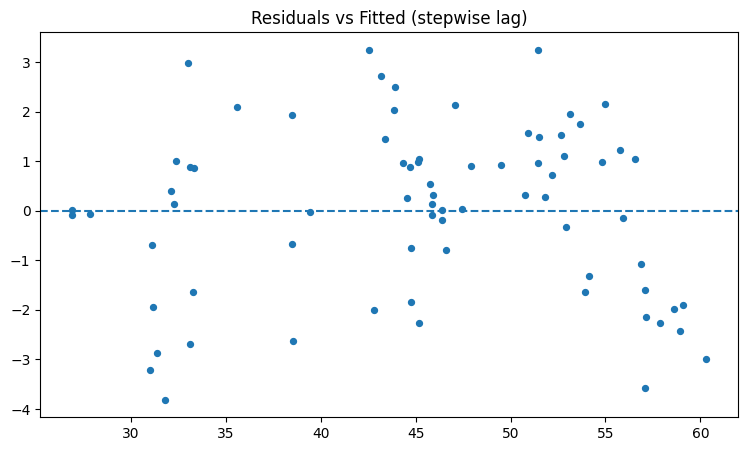

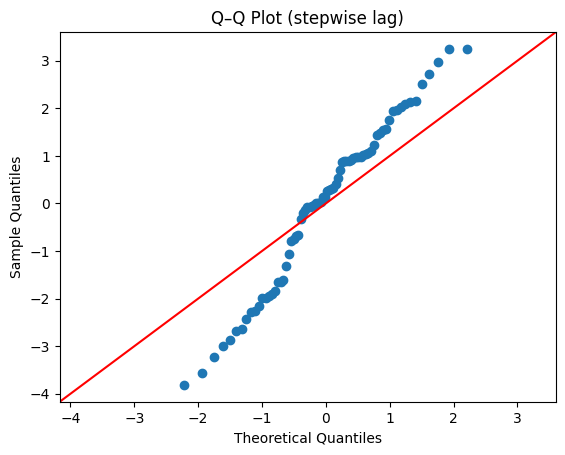

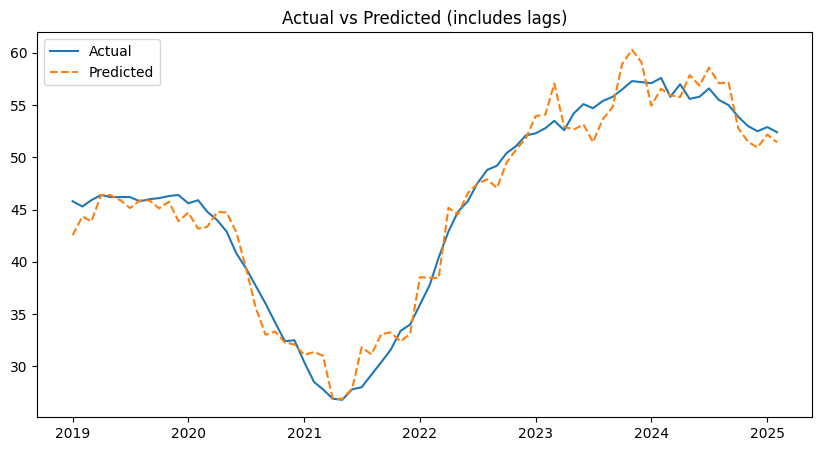

['inflation_rate', 'unemployment_rate', 'gdp_rate', 'business_investment_rate', 'electricity_price_rate', 'regular_pay_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.967
Model:                                         OLS   Adj. R-squared:                  0.962
Method:                              Least Squares   F-statistic:                     271.0
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           7.60e-47
Time:                                     21:56:30   Log-Likelihood:                -144.94
No. Observations:                               74   AIC:                             307.9
Df Residuals:                                   65   BIC:                             328.6
Df Model:                                        8                                        

In [19]:
# checking model for all inflation variables just in case, which shows that current inflation is
# statistially insognificant compared to lagged ones, so we keep model with only 12 and 24 lags
model_infl_all, diag_infl_all, xcols_used6 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["inflation_rate","unemployment_rate", "gdp_rate",
                 "business_investment_rate", "electricity_price_rate",
                 "regular_pay_rate", "inflation_rate_lag12", "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used6)
print(model_infl_all.summary())
print(diag_infl_all)

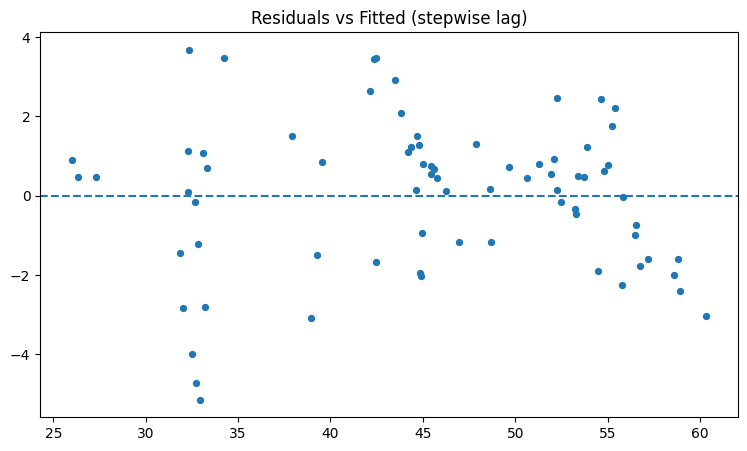

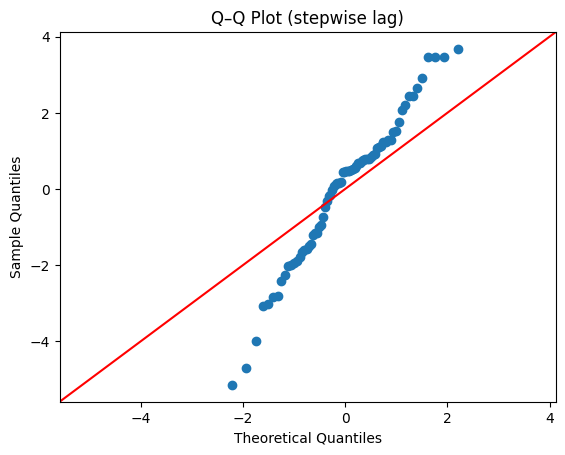

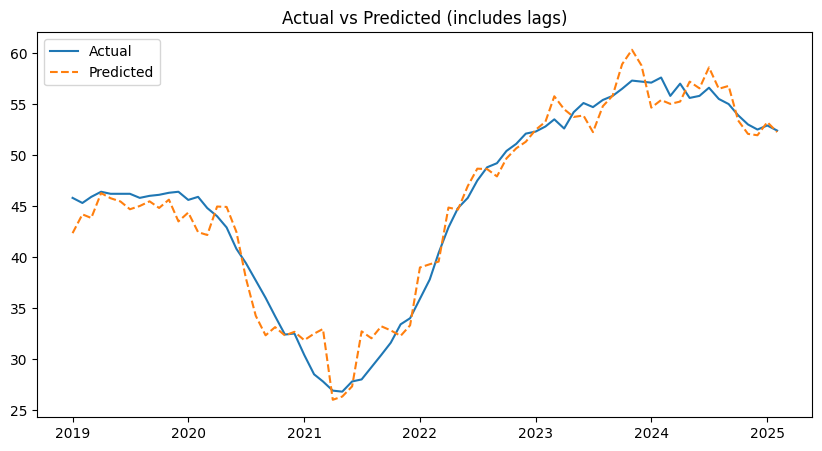

['unemployment_rate', 'gdp_rate', 'business_investment_rate', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.960
Model:                                         OLS   Adj. R-squared:                  0.956
Method:                              Least Squares   F-statistic:                     161.6
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           7.58e-38
Time:                                     21:56:30   Log-Likelihood:                -151.51
No. Observations:                               74   AIC:                             317.0
Df Residuals:                                   67   BIC:                             333.1
Df Model:                                        6                                         
Covariance Type:                    

In [20]:
#removed pay_rate to stabilise for concerningly high vif values and also pay became insignifican when adding both 12 and 24 month inflation variables
model_infl_12and24_no_pay, diag_infl_12and24_no_pay, xcols_used_ = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate",
                 "business_investment_rate", "electricity_price_rate",
                 "inflation_rate_lag12", "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used_)
print(model_infl_12and24_no_pay.summary())
print(diag_infl_12and24_no_pay)

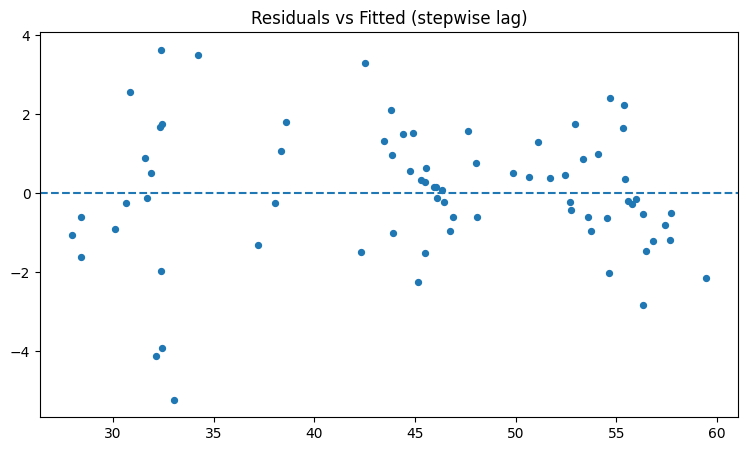

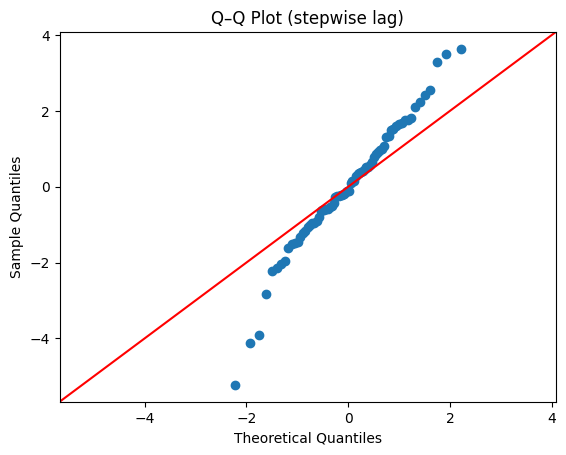

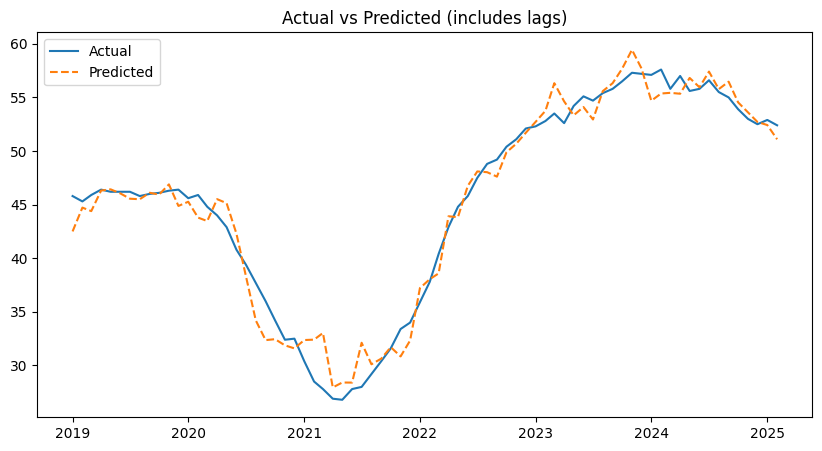

['unemployment_rate', 'unemployment_rate_lag12', 'gdp_rate', 'business_investment_rate', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.969
Model:                                         OLS   Adj. R-squared:                  0.966
Method:                              Least Squares   F-statistic:                     519.4
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           3.97e-55
Time:                                     21:56:31   Log-Likelihood:                -141.52
No. Observations:                               74   AIC:                             299.0
Df Residuals:                                   66   BIC:                             317.5
Df Model:                                        7                                         
Covarianc

In [21]:
# checking model for all variables from model above (12 and 24 month infl and no pay_rate) + unemployment lag 12
model_unemp_lag12, diag_unemp_lag12, xcols_used7 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "unemployment_rate_lag12",
                 "gdp_rate", "business_investment_rate",
                 "electricity_price_rate","inflation_rate_lag12",
                 "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used7)
print(model_unemp_lag12.summary())
print(diag_unemp_lag12)

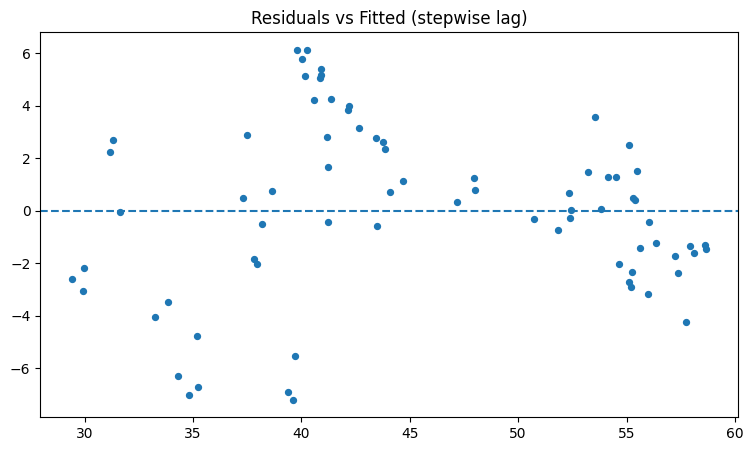

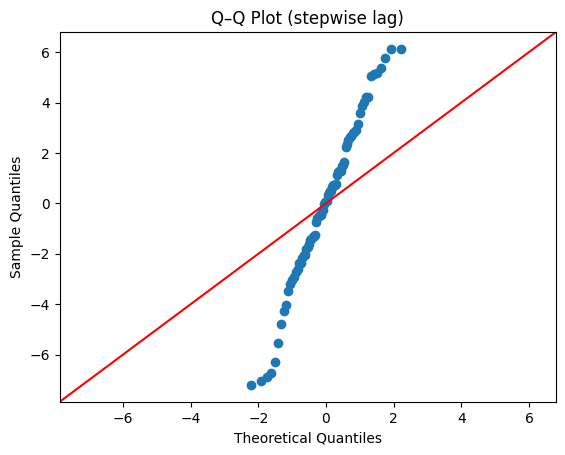

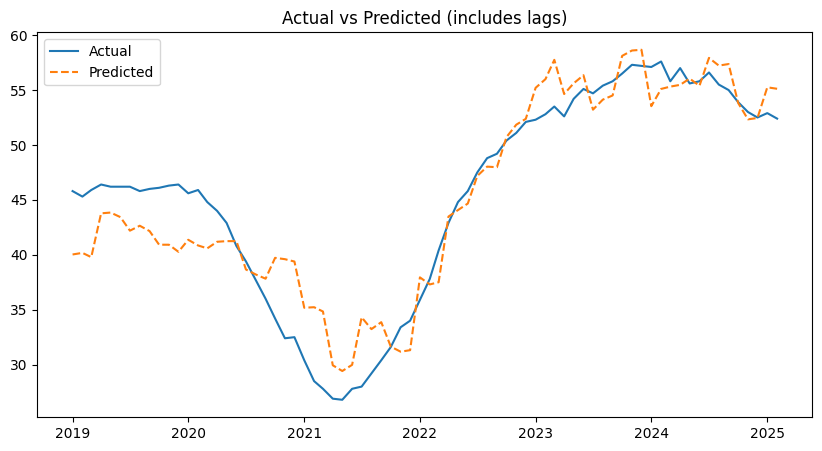

['unemployment_rate_lag12', 'gdp_rate', 'business_investment_rate', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.878
Model:                                         OLS   Adj. R-squared:                  0.867
Method:                              Least Squares   F-statistic:                     202.3
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           6.57e-41
Time:                                     21:56:32   Log-Likelihood:                -192.88
No. Observations:                               74   AIC:                             399.8
Df Residuals:                                   67   BIC:                             415.9
Df Model:                                        6                                         
Covariance Type:              

In [22]:
# our VIFs values are enormous for unemployment, so I am checking to see unemployment lag 12
# without current unemployment variable.
# it becomes insifnificant, which shows collinearity
# while both were significant together, the lagged effect became weak when alone,
# indicating substantial overlap between the two series, so to avoid exploded VIFs
# later, we decided to keep only current unemployment
model_unemp_onlylag12, diag_unemp_onlylag12, xcols_used8 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate_lag12","gdp_rate",
                 "business_investment_rate","electricity_price_rate",
                 "inflation_rate_lag12", "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used8)
print(model_unemp_onlylag12.summary())
print(diag_unemp_onlylag12)

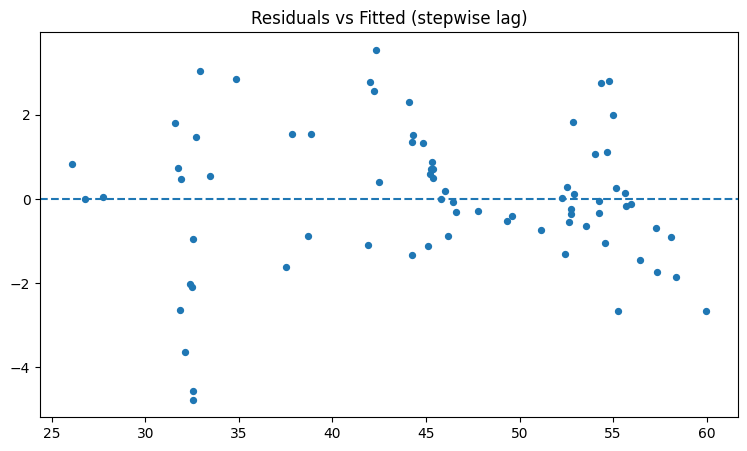

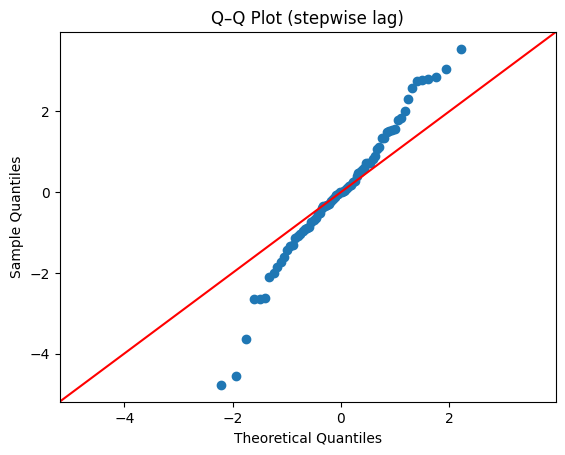

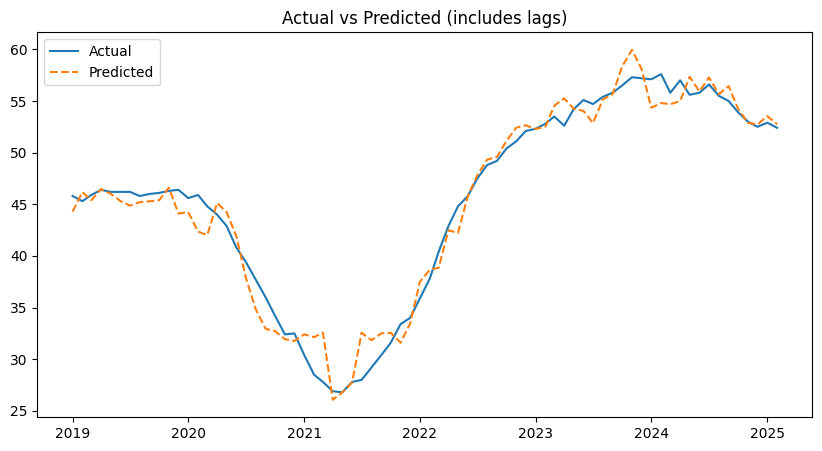

['unemployment_rate', 'unemployment_rate_lag24', 'gdp_rate', 'business_investment_rate', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.968
Model:                                         OLS   Adj. R-squared:                  0.965
Method:                              Least Squares   F-statistic:                     320.6
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           2.21e-48
Time:                                     21:56:32   Log-Likelihood:                -142.89
No. Observations:                               74   AIC:                             301.8
Df Residuals:                                   66   BIC:                             320.2
Df Model:                                        7                                         
Covarianc

In [23]:
model_unemp_lag24, diag_unemp_lag24, xcols_usedd = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "unemployment_rate_lag24",
                 "gdp_rate", "business_investment_rate",
                 "electricity_price_rate","inflation_rate_lag12",
                 "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_usedd)
print(model_unemp_lag24.summary())
print(diag_unemp_lag24)

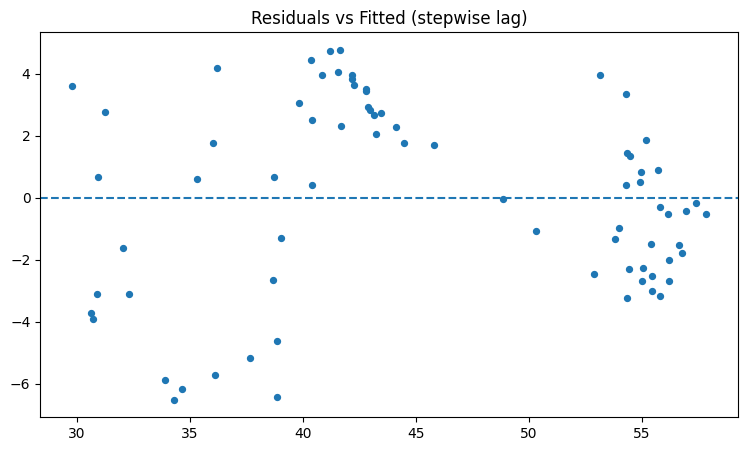

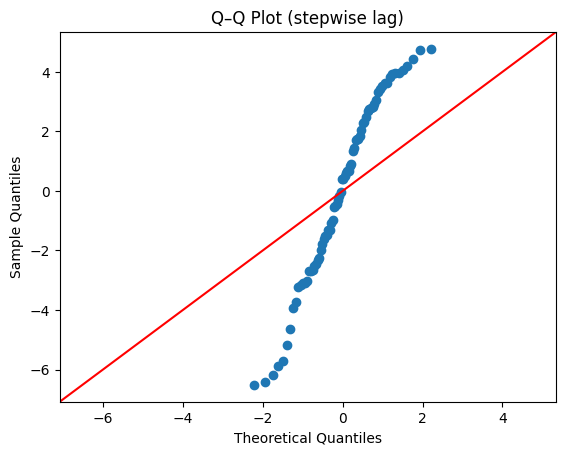

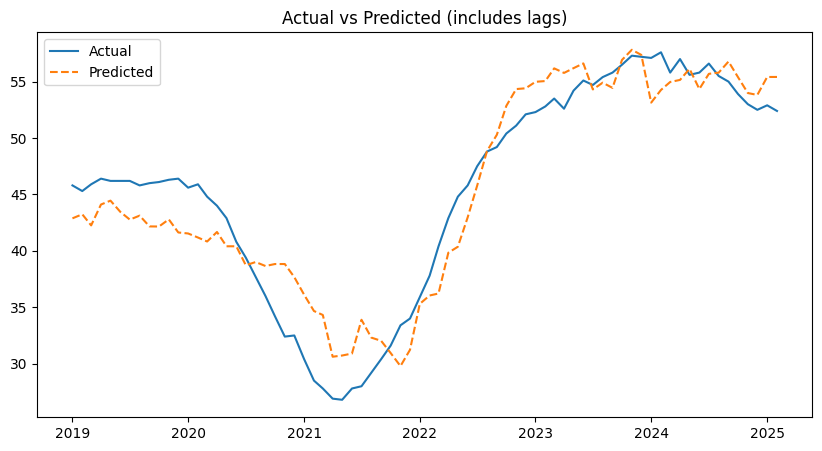

['unemployment_rate_lag24', 'gdp_rate', 'business_investment_rate', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.894
Model:                                         OLS   Adj. R-squared:                  0.884
Method:                              Least Squares   F-statistic:                     70.33
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           5.57e-27
Time:                                     21:56:33   Log-Likelihood:                -187.69
No. Observations:                               74   AIC:                             389.4
Df Residuals:                                   67   BIC:                             405.5
Df Model:                                        6                                         
Covariance Type:              

In [24]:
# checking for only lag 24 to see whether it can stand on its own within the model
# which concludes that it's insignificant, and DW statistic < 0.5 and smal BP test
# indicate overall bad fir, so we stick obly with current unemployment variable
model_unemp_onlylag24, diag_unemp_onlylag24, xcols_used9 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate_lag24","gdp_rate",
                 "business_investment_rate","electricity_price_rate",
                 "inflation_rate_lag12", "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used9)
print(model_unemp_onlylag24.summary())
print(diag_unemp_onlylag24)

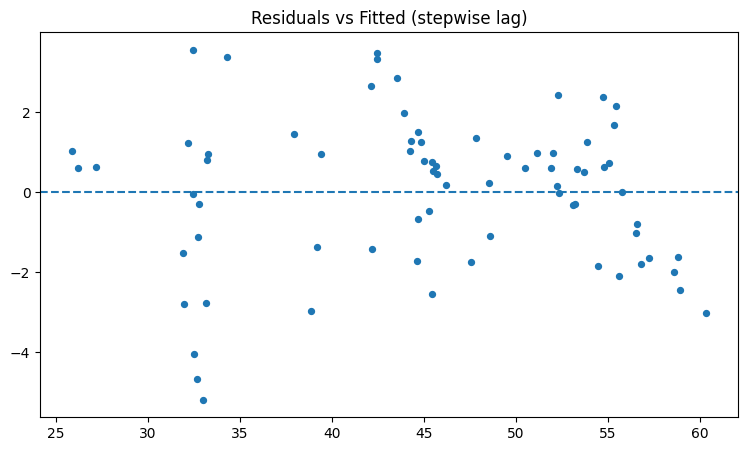

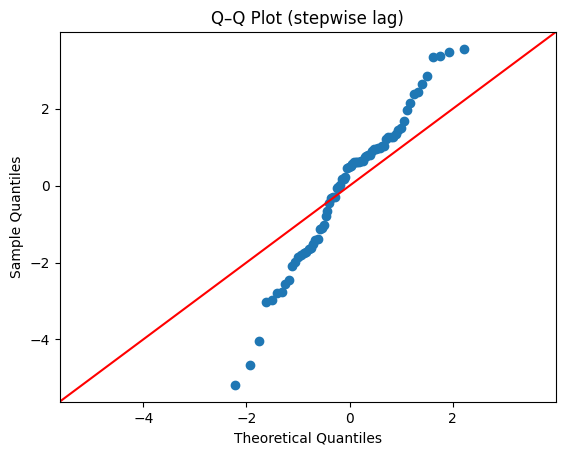

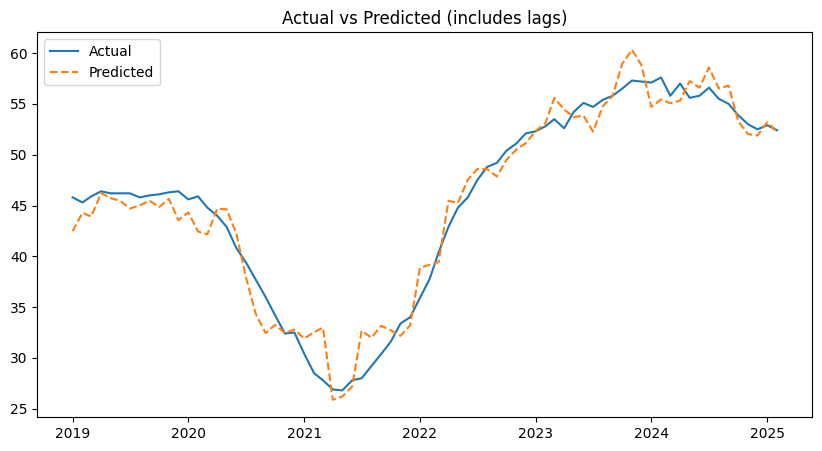

['unemployment_rate', 'gdp_rate', 'gdp_rate_lag12', 'business_investment_rate', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.960
Model:                                         OLS   Adj. R-squared:                  0.956
Method:                              Least Squares   F-statistic:                     240.8
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           2.00e-44
Time:                                     21:56:33   Log-Likelihood:                -151.26
No. Observations:                               74   AIC:                             318.5
Df Residuals:                                   66   BIC:                             337.0
Df Model:                                        7                                         
Covariance Type:  

In [25]:
# doing model with infl lag 12 and 24 + no pay_rate + gdp lag 12
# which ended up being insignificant
model_gdp_lag12, diag_gdp_lag12, xcols_used10 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate",
                 "gdp_rate_lag12", "business_investment_rate",
                 "electricity_price_rate","inflation_rate_lag12",
                 "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used10)
print(model_gdp_lag12.summary())
print(diag_gdp_lag12)

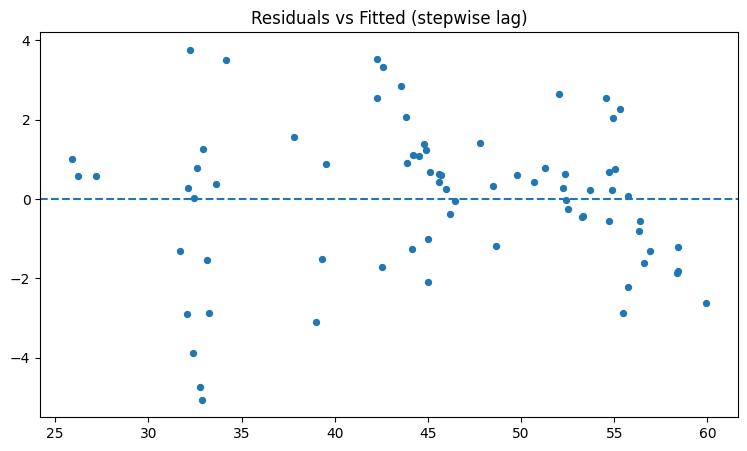

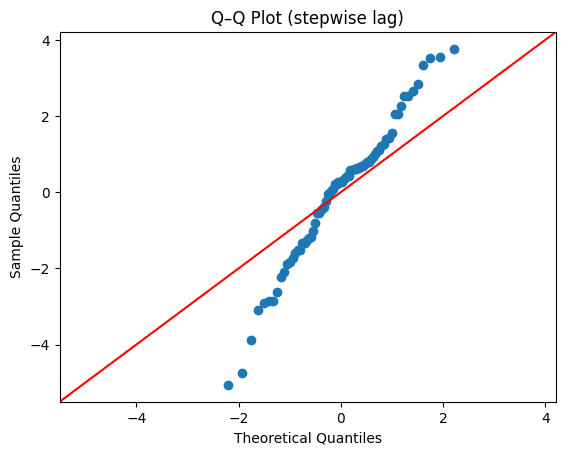

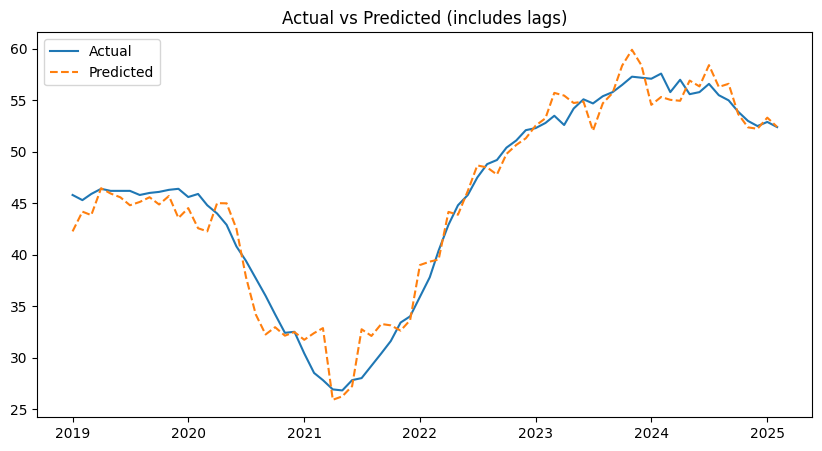

['unemployment_rate', 'gdp_rate', 'gdp_rate_lag24', 'business_investment_rate', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.961
Model:                                         OLS   Adj. R-squared:                  0.957
Method:                              Least Squares   F-statistic:                     192.8
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           2.21e-41
Time:                                     21:56:34   Log-Likelihood:                -150.55
No. Observations:                               74   AIC:                             317.1
Df Residuals:                                   66   BIC:                             335.5
Df Model:                                        7                                         
Covariance Type:  

In [26]:
# model from above but with gdp lag 24 instead shows that both current and gdp lag 24 are significant
model_gdp_lag24, diag_gdp_lag24, xcols_used11 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate",
                 "gdp_rate_lag24", "business_investment_rate",
                 "electricity_price_rate","inflation_rate_lag12",
                 "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used11)
print(model_gdp_lag24.summary())
print(diag_gdp_lag24)

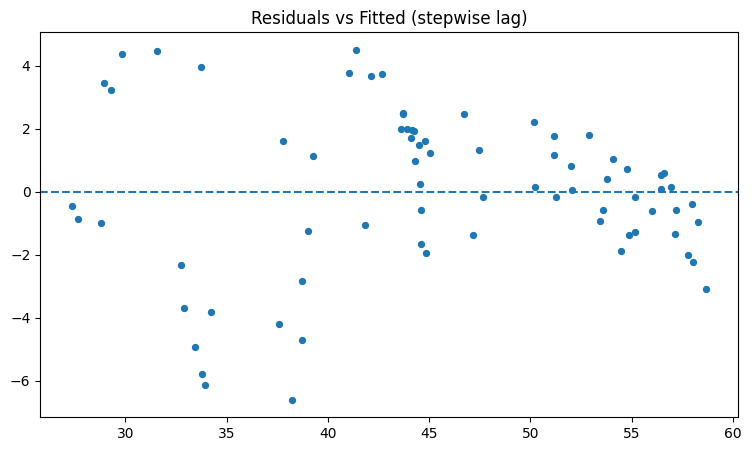

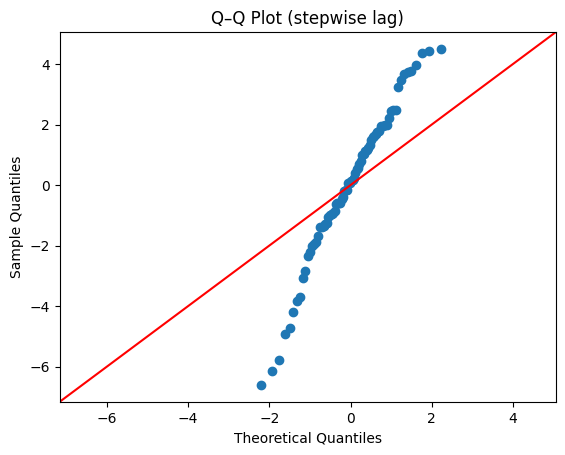

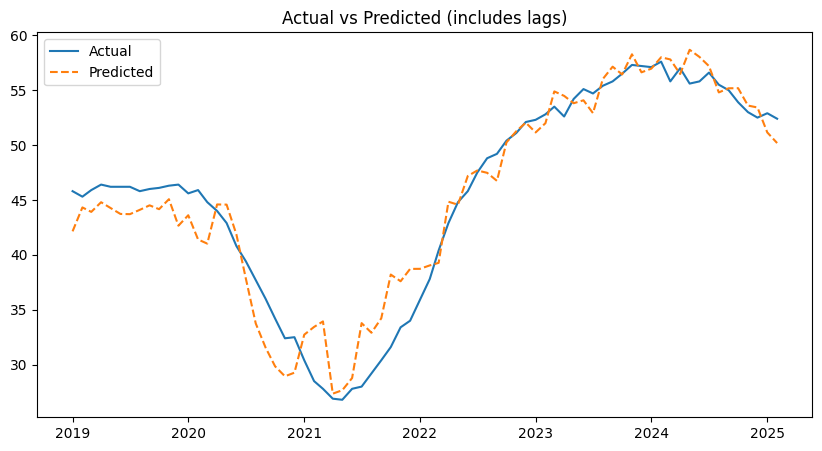

['unemployment_rate', 'gdp_rate_lag24', 'business_investment_rate', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.928
Model:                                         OLS   Adj. R-squared:                  0.922
Method:                              Least Squares   F-statistic:                     155.3
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           2.65e-37
Time:                                     21:56:34   Log-Likelihood:                -173.27
No. Observations:                               74   AIC:                             360.5
Df Residuals:                                   67   BIC:                             376.7
Df Model:                                        6                                         
Covariance Type:              

In [27]:
model_gdp_only_lag24, diag_gdp_only_lag24, xcols_used11_ = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate",
                 "gdp_rate_lag24", "business_investment_rate",
                 "electricity_price_rate","inflation_rate_lag12",
                 "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used11_)
print(model_gdp_only_lag24.summary())
print(diag_gdp_only_lag24)

In [28]:
# checking correlation with all variables to check for supression effect to
# to ensure that highly correlated predictors, such as GDP and business investment, were not distorting each other’s coefficients
# correlation of gdp and business investemtn is extremely high,
# so testing the models without either business investment or gdp
df_master[["company_insolvency_rate_per_10k","gdp_rate",
    "gdp_rate_lag24","business_investment_rate"]].corr().round(3)

,company_insolvency_rate_per_10k,gdp_rate,gdp_rate_lag24,business_investment_rate
company_insolvency_rate_per_10k,1.000,-0.209,0.228,0.157
gdp_rate,-0.209,1.000,-0.088,0.879
gdp_rate_lag24,0.228,-0.088,1.000,-0.073
business_investment_rate,0.157,0.879,-0.073,1.000


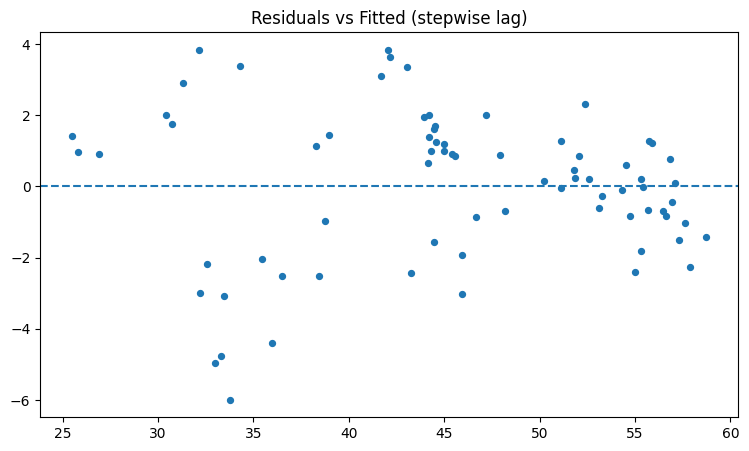

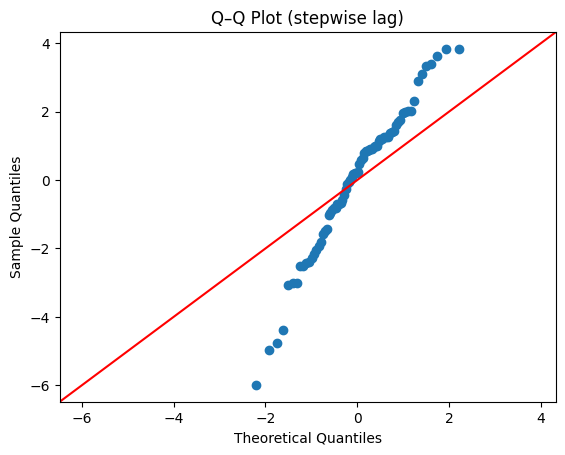

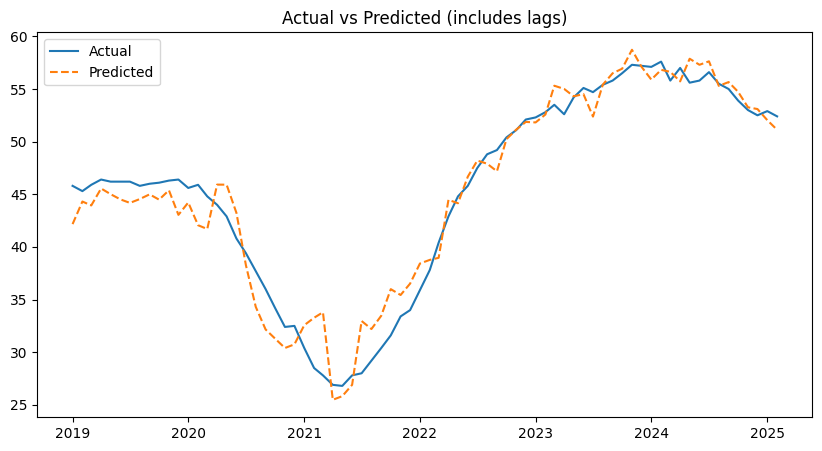

['unemployment_rate', 'gdp_rate', 'gdp_rate_lag24', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.950
Model:                                         OLS   Adj. R-squared:                  0.945
Method:                              Least Squares   F-statistic:                     148.5
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           1.06e-36
Time:                                     21:56:35   Log-Likelihood:                -159.80
No. Observations:                               74   AIC:                             333.6
Df Residuals:                                   67   BIC:                             349.7
Df Model:                                        6                                         
Covariance Type:                              

In [29]:
# model without business ivestment
model_gdp_lag24_no_binv, diag_gdp_lag24_no_binv, xcols_used12 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate",
                 "gdp_rate_lag24","electricity_price_rate",
                 "inflation_rate_lag12", "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used12)
print(model_gdp_lag24_no_binv.summary())
print(diag_gdp_lag24_no_binv)

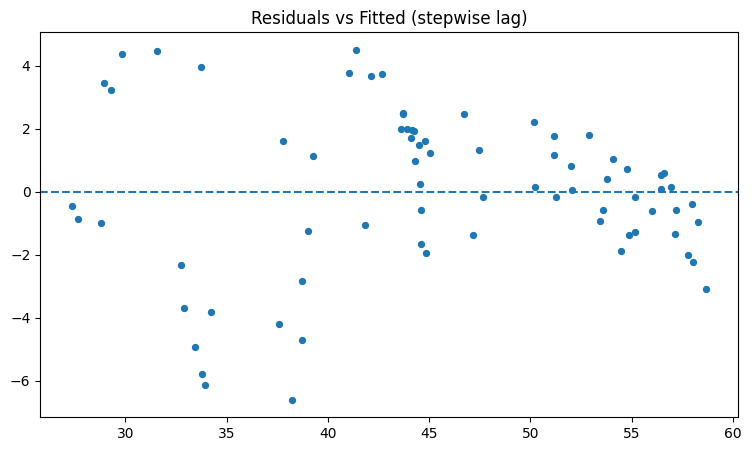

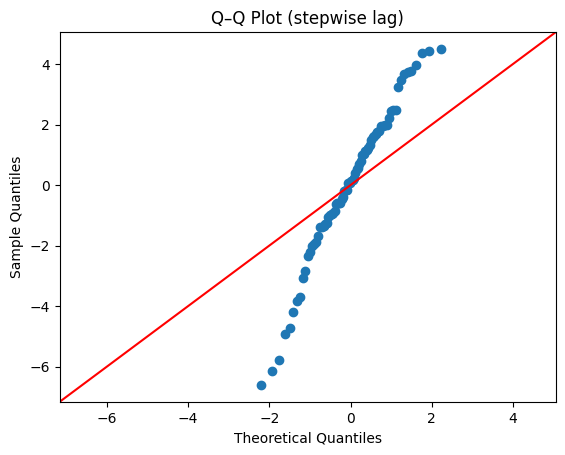

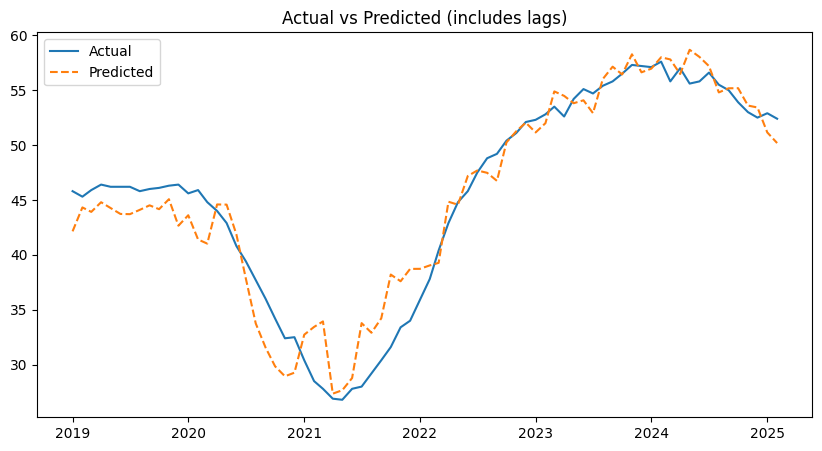

['unemployment_rate', 'gdp_rate_lag24', 'business_investment_rate', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.928
Model:                                         OLS   Adj. R-squared:                  0.922
Method:                              Least Squares   F-statistic:                     155.3
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           2.65e-37
Time:                                     21:56:35   Log-Likelihood:                -173.27
No. Observations:                               74   AIC:                             360.5
Df Residuals:                                   67   BIC:                             376.7
Df Model:                                        6                                         
Covariance Type:              

In [30]:
# model without current gdp variable
model_gdp_onlylag24, diag_gdp_onlylag24, xcols_used13 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate_lag24",
                 "business_investment_rate", "electricity_price_rate",
                 "inflation_rate_lag12", "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used13)
print(model_gdp_onlylag24.summary())
print(diag_gdp_onlylag24)

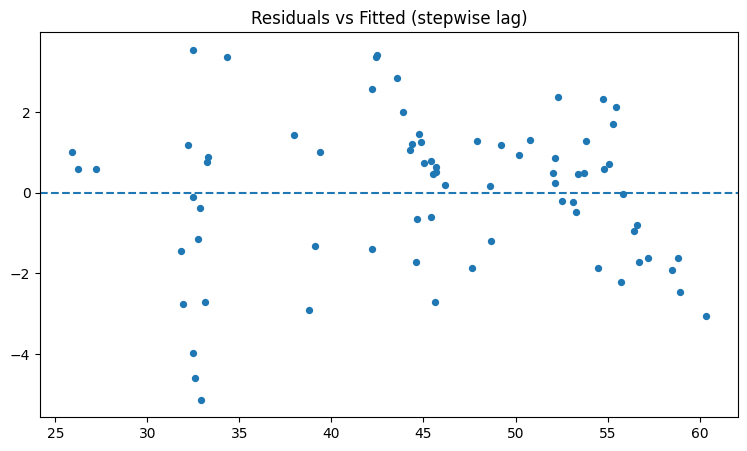

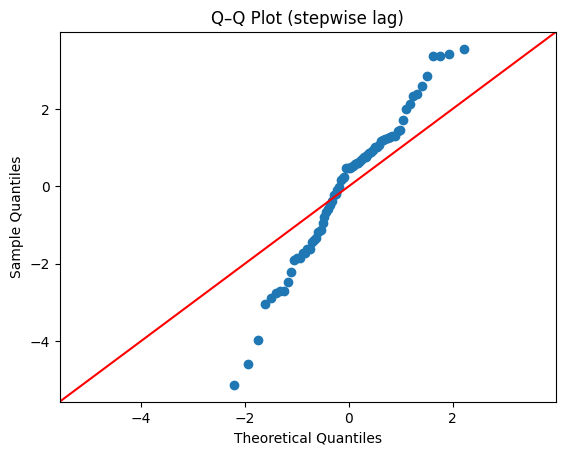

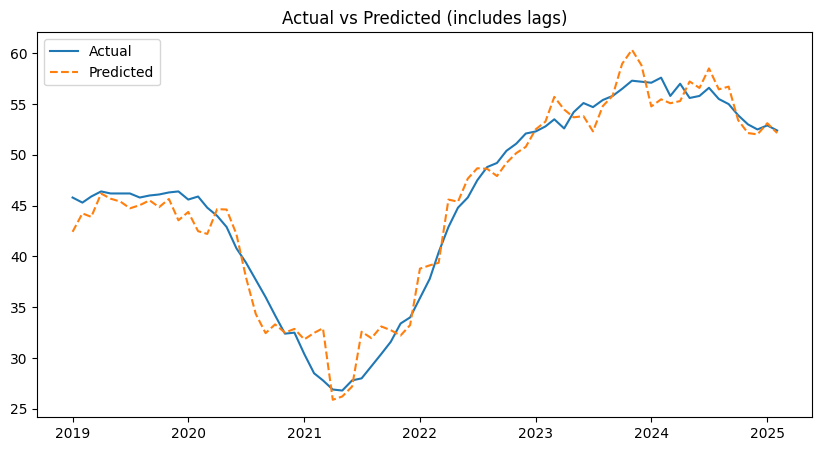

['unemployment_rate', 'gdp_rate', 'business_investment_rate', 'business_investment_rate_lag12', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.960
Model:                                         OLS   Adj. R-squared:                  0.956
Method:                              Least Squares   F-statistic:                     185.2
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           7.77e-41
Time:                                     21:56:36   Log-Likelihood:                -151.08
No. Observations:                               74   AIC:                             318.2
Df Residuals:                                   66   BIC:                             336.6
Df Model:                                        7                                         
Co

In [31]:
model_binv_lag12, diag_binv_lag12, xcols_used_binv_lag12 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate",
                 "business_investment_rate", "business_investment_rate_lag12",
                 "electricity_price_rate","inflation_rate_lag12",
                 "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used_binv_lag12)
print(model_binv_lag12.summary())
print(diag_binv_lag12)

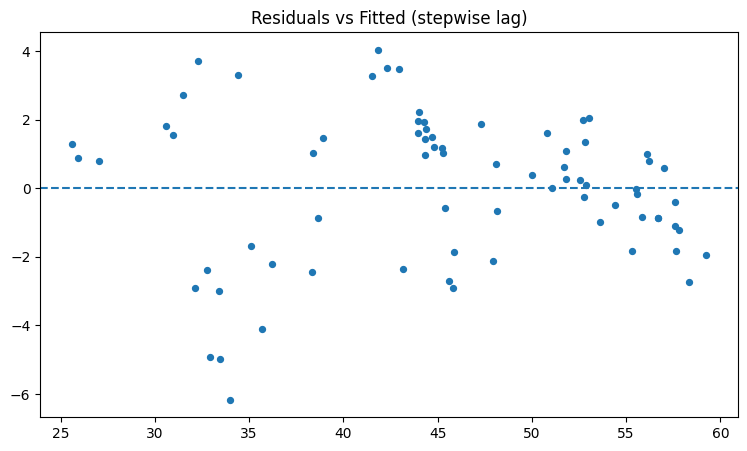

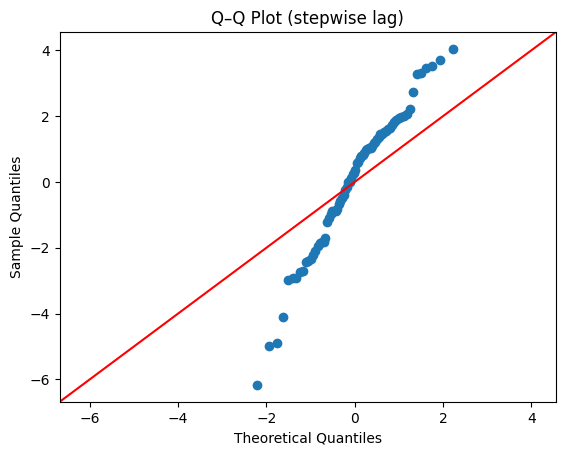

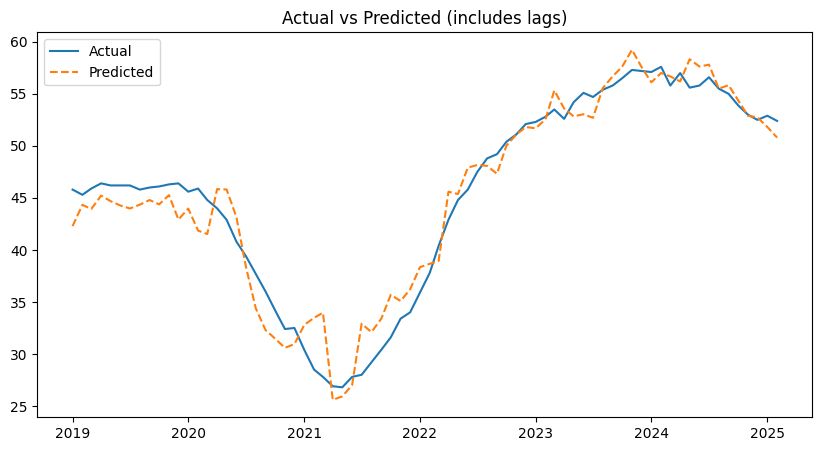

['unemployment_rate', 'gdp_rate', 'business_investment_rate_lag12', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.948
Model:                                         OLS   Adj. R-squared:                  0.943
Method:                              Least Squares   F-statistic:                     107.0
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           2.42e-32
Time:                                     21:56:36   Log-Likelihood:                -161.28
No. Observations:                               74   AIC:                             336.6
Df Residuals:                                   67   BIC:                             352.7
Df Model:                                        6                                         
Covariance Type:              

In [32]:
model_binv_only_lag12, diag_binv_only_lag12, xcols_used_binv_only_lag12 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate",
                 "business_investment_rate_lag12",
                 "electricity_price_rate","inflation_rate_lag12",
                 "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used_binv_only_lag12)
print(model_binv_only_lag12.summary())
print(diag_binv_only_lag12)

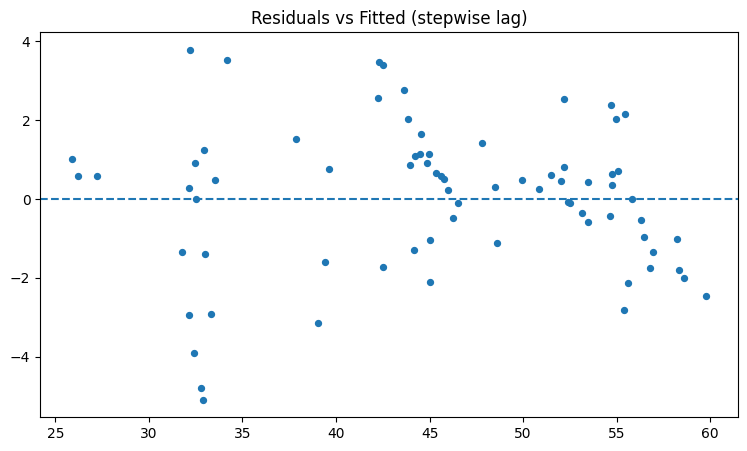

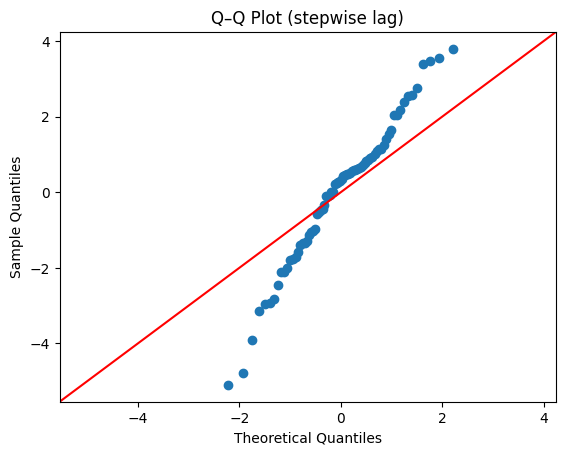

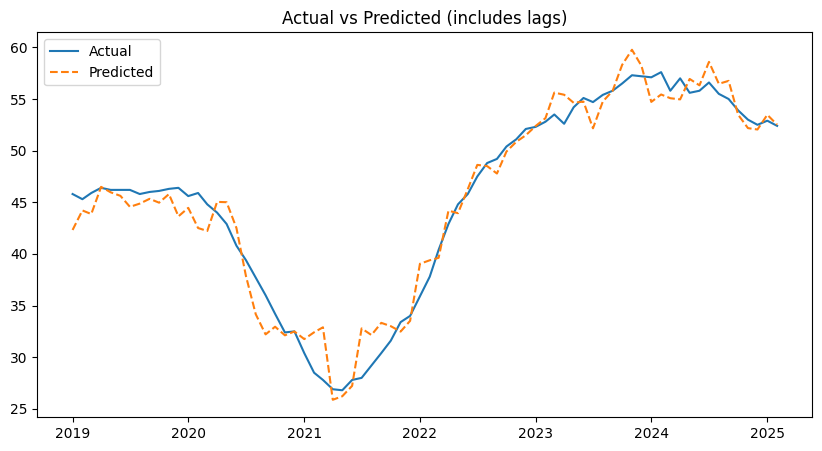

['unemployment_rate', 'gdp_rate', 'business_investment_rate', 'business_investment_rate_lag24', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.961
Model:                                         OLS   Adj. R-squared:                  0.957
Method:                              Least Squares   F-statistic:                     191.0
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           2.96e-41
Time:                                     21:56:37   Log-Likelihood:                -150.64
No. Observations:                               74   AIC:                             317.3
Df Residuals:                                   66   BIC:                             335.7
Df Model:                                        7                                         
Co

In [33]:
model_binv_lag24, diag_binv_lag24, xcols_used_binv_lag24 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate",
                 "business_investment_rate", "business_investment_rate_lag24",
                 "electricity_price_rate","inflation_rate_lag12",
                 "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used_binv_lag24)
print(model_binv_lag24.summary())
print(diag_binv_lag24)

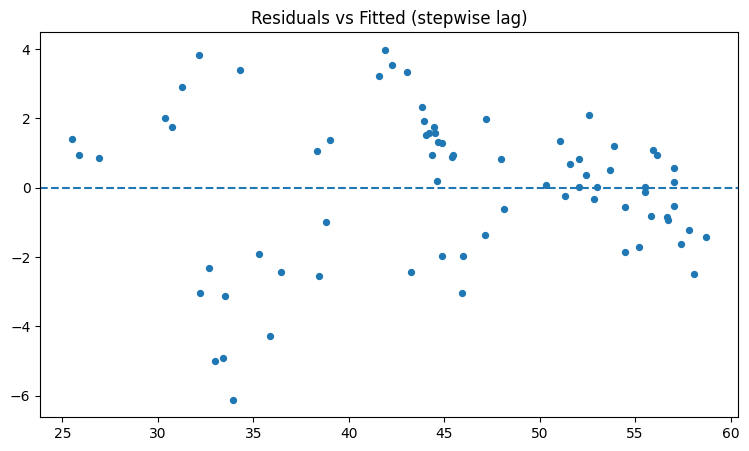

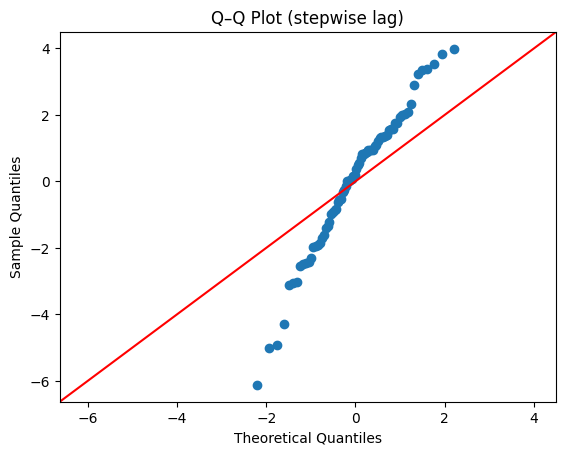

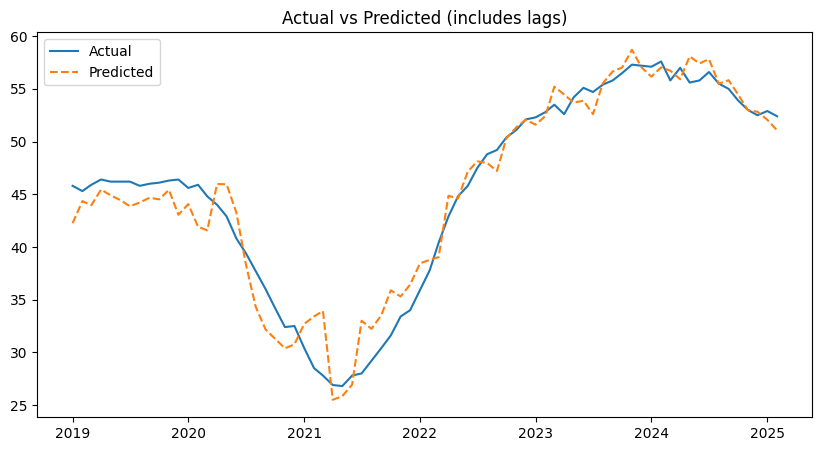

['unemployment_rate', 'gdp_rate', 'business_investment_rate_lag24', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.949
Model:                                         OLS   Adj. R-squared:                  0.944
Method:                              Least Squares   F-statistic:                     174.6
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           6.73e-39
Time:                                     21:56:37   Log-Likelihood:                -160.69
No. Observations:                               74   AIC:                             335.4
Df Residuals:                                   67   BIC:                             351.5
Df Model:                                        6                                         
Covariance Type:              

In [34]:
model_binv_only_lag24, diag_binv_only_lag24, xcols_used_binv_only_lag24 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate",
                 "business_investment_rate_lag24",
                 "electricity_price_rate","inflation_rate_lag12",
                 "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used_binv_only_lag24)
print(model_binv_only_lag24.summary())
print(diag_binv_only_lag24)

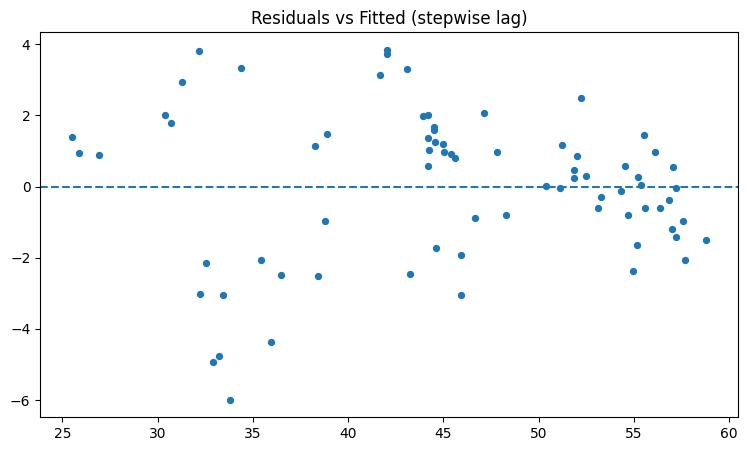

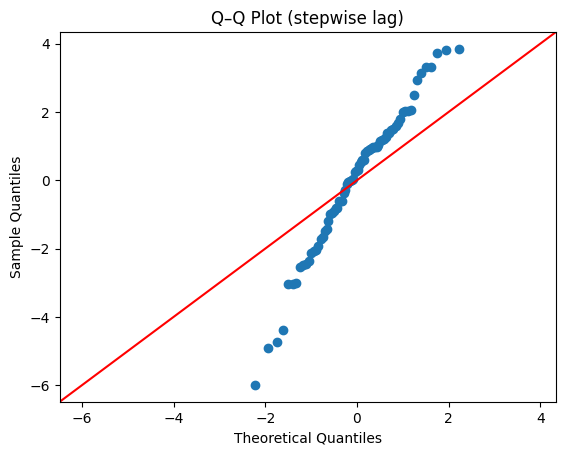

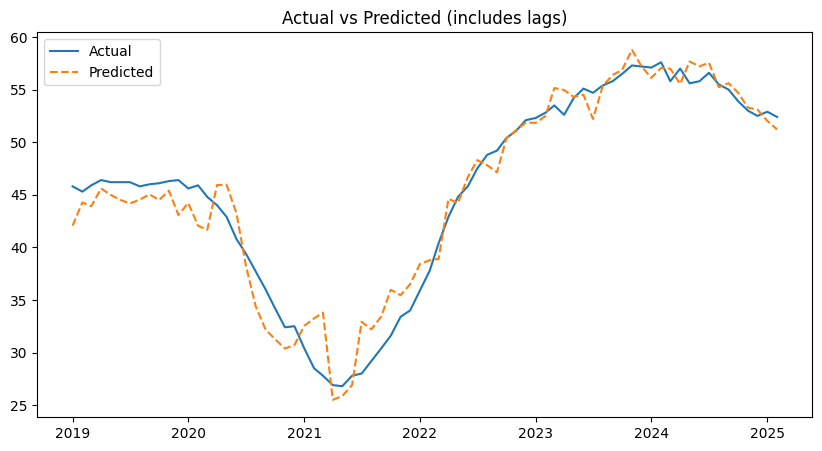

['unemployment_rate', 'gdp_rate', 'gdp_rate_lag24', 'electricity_price_rate', 'electricity_price_rate_lag12', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.950
Model:                                         OLS   Adj. R-squared:                  0.945
Method:                              Least Squares   F-statistic:                     123.9
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           1.92e-35
Time:                                     21:56:38   Log-Likelihood:                -159.73
No. Observations:                               74   AIC:                             335.5
Df Residuals:                                   66   BIC:                             353.9
Df Model:                                        7                                         
Covariance Typ

In [35]:
# we removed business investment
# and now checking the model with infl lag 12 and 24
# with no pay_rate and business_investment for electricity lag 12
model_electricity_lag12, diag_electricity_lag12, xcols_used14 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=[
        "unemployment_rate", "gdp_rate","gdp_rate_lag24",
        "electricity_price_rate", "electricity_price_rate_lag12",
        "inflation_rate_lag12", "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used14)
print(model_electricity_lag12.summary())
print(diag_electricity_lag12)

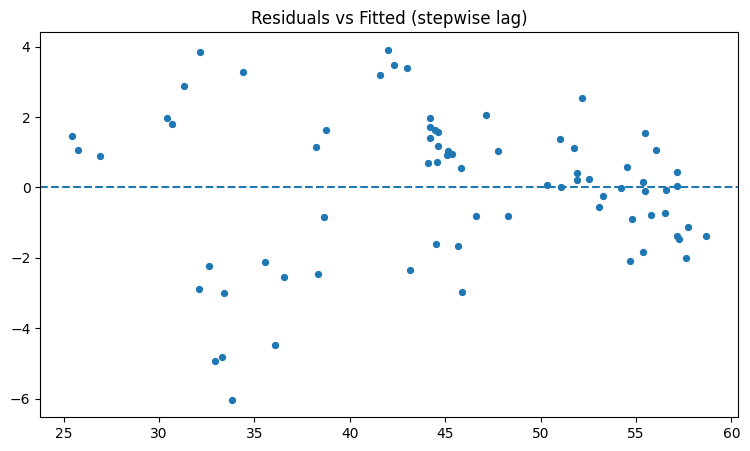

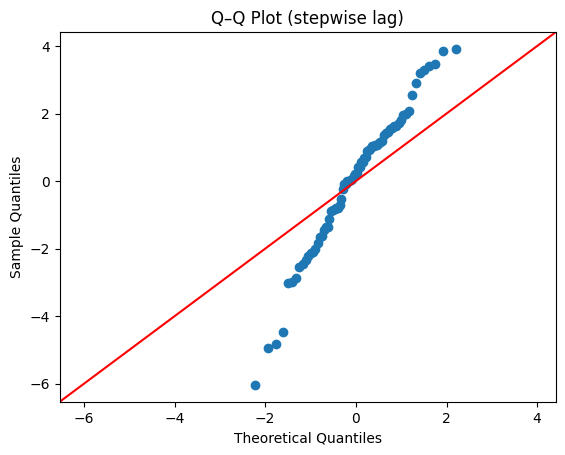

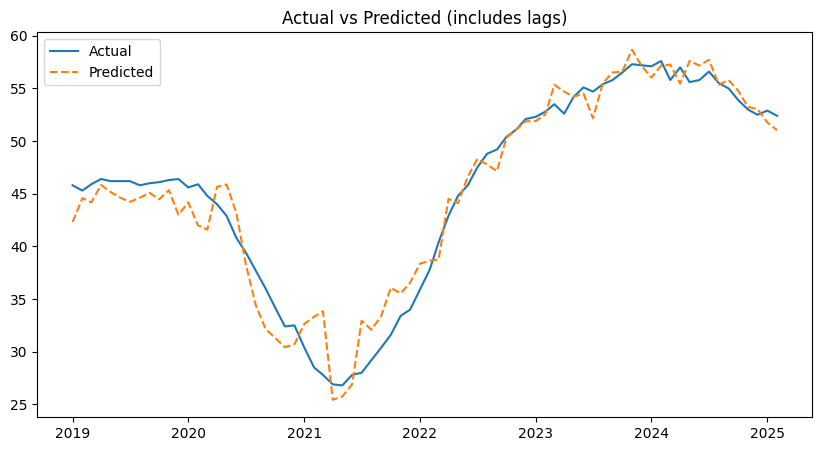

['unemployment_rate', 'gdp_rate', 'gdp_rate_lag24', 'electricity_price_rate', 'electricity_price_rate_lag24', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.950
Model:                                         OLS   Adj. R-squared:                  0.945
Method:                              Least Squares   F-statistic:                     156.0
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           1.63e-38
Time:                                     21:56:39   Log-Likelihood:                -159.61
No. Observations:                               74   AIC:                             335.2
Df Residuals:                                   66   BIC:                             353.6
Df Model:                                        7                                         
Covariance Typ

In [36]:
# electricity with lag 12 wasnt significant so we checking for lag 24
model_electricity_lag24, diag_electricity_lag24, xcols_used15 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["unemployment_rate", "gdp_rate","gdp_rate_lag24",
                 "electricity_price_rate", "electricity_price_rate_lag24",
                 "inflation_rate_lag12", "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})
print(xcols_used15)
print(model_electricity_lag24.summary())
print(diag_electricity_lag24)

In [37]:
# neither lags were significant so this is our final lagged model
final_lagged_model = model_gdp_lag24_no_binv
final_lagged_diag = diag_gdp_lag24_no_binv
final_lagged_xcols = xcols_used12

print(final_lagged_xcols)
print(final_lagged_model.summary())
print(final_lagged_diag)

['unemployment_rate', 'gdp_rate', 'gdp_rate_lag24', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.950
Model:                                         OLS   Adj. R-squared:                  0.945
Method:                              Least Squares   F-statistic:                     148.5
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           1.06e-36
Time:                                     21:56:39   Log-Likelihood:                -159.80
No. Observations:                               74   AIC:                             333.6
Df Residuals:                                   67   BIC:                             349.7
Df Model:                                        6                                         
Covariance Type:                              

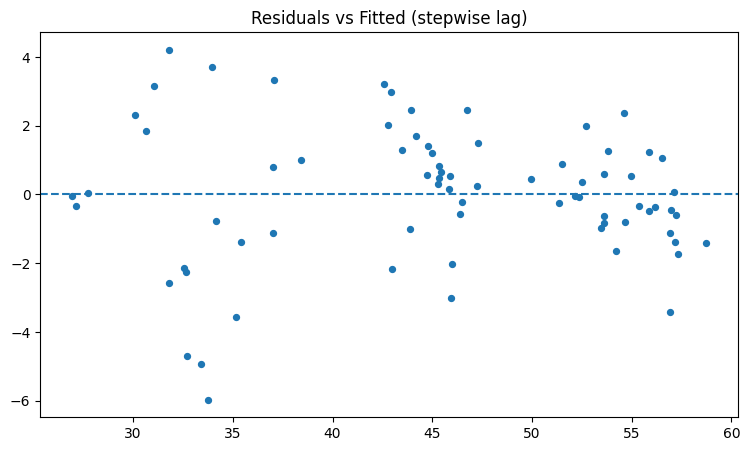

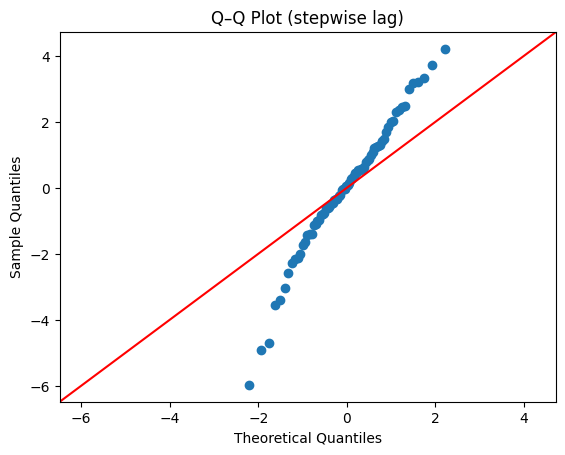

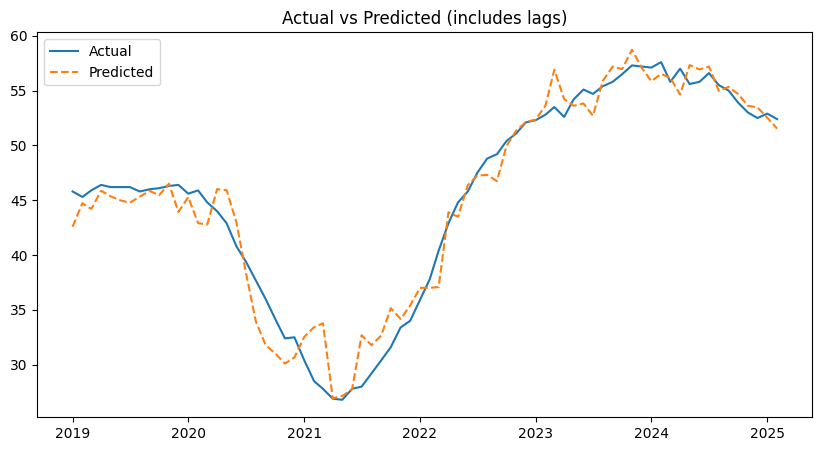

['company_insolvency_rate_lag12', 'unemployment_rate', 'gdp_rate', 'gdp_rate_lag24', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.956
Model:                                         OLS   Adj. R-squared:                  0.951
Method:                              Least Squares   F-statistic:                     233.6
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           5.21e-44
Time:                                     21:56:41   Log-Likelihood:                -155.12
No. Observations:                               74   AIC:                             326.2
Df Residuals:                                   66   BIC:                             344.7
Df Model:                                        7                                         
Covariance Ty

In [38]:
# adding lagged dependent variable with lag 12 to check for persistency
# the lagged term is significant (p < 0.01) but it introduces severe multicollinearity (VIF = 185)
# and worsens overall diagnostics.
# this suggests the lagged dependent variable overlaps heavily with other macro lags
# rather than capturing an independent autoregressive process.
# therefore, this model demonstrates persistence but is unsuitable as a main specification.
model_final_dep_var, diag_final_dep_var, xcols_used_final_dep_var = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["company_insolvency_rate_lag12",
                 "unemployment_rate",
                 "gdp_rate",
                 "gdp_rate_lag24",
                 "electricity_price_rate",
                 "inflation_rate_lag12",
                 "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})

print(xcols_used_final_dep_var)
print(model_final_dep_var.summary())
print(diag_final_dep_var)

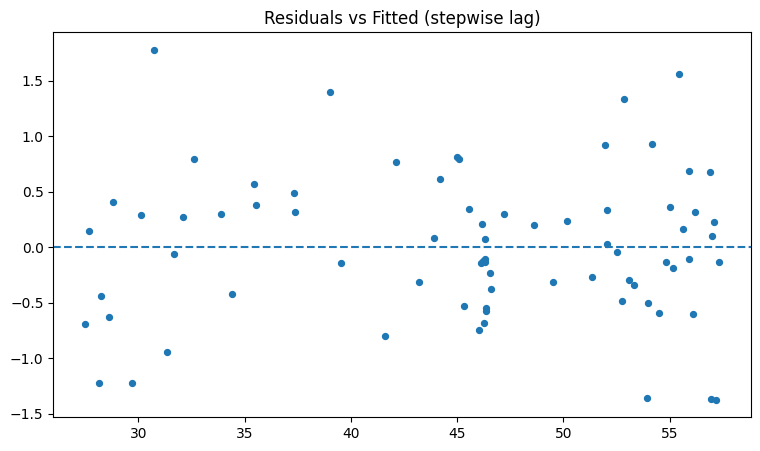

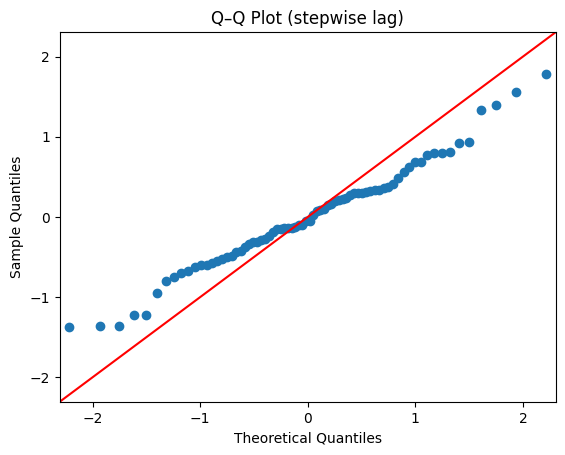

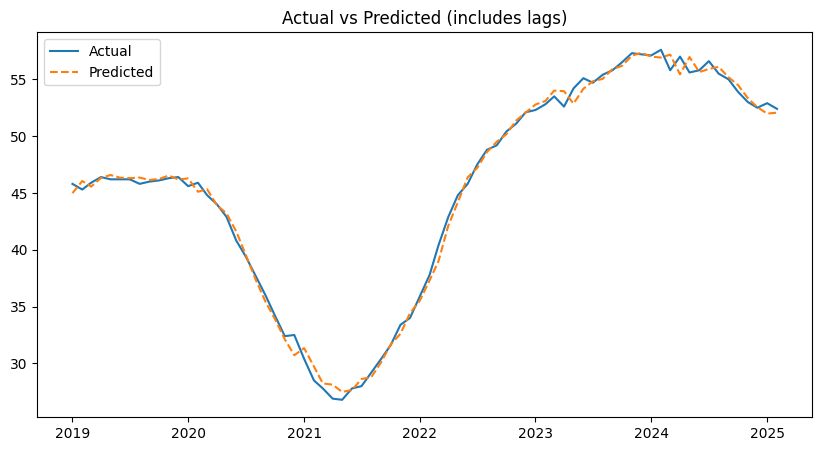

['company_insolvency_rate_lag1', 'unemployment_rate', 'gdp_rate', 'gdp_rate_lag24', 'electricity_price_rate', 'inflation_rate_lag12', 'inflation_rate_lag24']
                                   OLS Regression Results                                  
Dep. Variable:     company_insolvency_rate_per_10k   R-squared:                       0.995
Model:                                         OLS   Adj. R-squared:                  0.995
Method:                              Least Squares   F-statistic:                     6873.
Date:                             Wed, 26 Nov 2025   Prob (F-statistic):           6.92e-92
Time:                                     21:56:42   Log-Likelihood:                -74.320
No. Observations:                               74   AIC:                             164.6
Df Residuals:                                   66   BIC:                             183.1
Df Model:                                        7                                         
Covariance Typ

In [39]:
# vifs exploded for lag 12, causing extreme multicollinearity, so decided to check a 1-month lag instead.
# 1-month lag is highly significant and removes autocorrelation issues (DW is around 2),
# but VIFs are still very high, meaning variables are strongly related and coefficients unstable.
# model basically overfits because recent insolvency rates already explain almost all variation.
# it confirms strong short-term persistence but makes the model unsuitable for interpretation.
model_final_dep_var2, diag_final_dep_var2, xcols_used_final_dep_var2 = add_lag_ols(
    df=df_master,
    y_col="company_insolvency_rate_per_10k",
    base_x_cols=["company_insolvency_rate_lag1",
                 "unemployment_rate",
                 "gdp_rate",
                 "gdp_rate_lag24",
                 "electricity_price_rate",
                 "inflation_rate_lag12",
                 "inflation_rate_lag24"],
    date_col="date",
    se_method="HAC",
    se_args={"maxlags": 12})

print(xcols_used_final_dep_var2)
print(model_final_dep_var2.summary())
print(diag_final_dep_var2)